# IEEE-CIS Fraud Detection: Exploratory Data Analysis

Break Through Tech AI Studio: Mastercard project.

## Setup

1. Install the dependencies by running the cell below once. It installs everything listed in `requirements.txt`, which should sit in the same folder as this notebook.
2. **Restart the kernel** after installing so the new packages load.
3. You need a Kaggle account and must accept the [IEEE-CIS Fraud Detection competition rules](https://www.kaggle.com/c/ieee-fraud-detection/rules) before the data can be downloaded. `kagglehub.login()` will prompt for your Kaggle username and API key.
4. Run the notebook top to bottom (**Kernel > Restart Kernel and Run All Cells**). Cells depend on earlier ones, so running them out of order can fail.

In [1]:
# %pip install -r requirements.txt

## Data Download

In [2]:
import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [4]:
# # Download latest version
# path = kagglehub.competition_download('ieee-fraud-detection')

# print("Path to competition files:", path)

from google.colab import drive
drive.mount('/content/drive/')


Mounted at /content/drive/


In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = "/content/drive/MyDrive/Raw_Data"

In [6]:
import os
print(os.listdir(path))  # see what files are actually there

['test_identity.csv', 'test_transaction.csv', 'train_identity.csv', 'train_transaction.csv']


### Locate Data Files in Google Drive

The `FileNotFoundError` indicates that the path `'/content/drive/MyDrive/Banking 1B Team Files/Raw Data'` does not exist. This could be due to a typo, or the files might be located in a different directory within your Google Drive.

Let's list the contents of your mounted Google Drive directories to help you find the correct path to your `train_transaction.csv`, `train_identity.csv`, `test_transaction.csv`, and `test_identity.csv` files. Once you find the correct directory, please update the `path` variable in cell `-Al6BTEqswYl` accordingly.

## Dataset Description

In this competition you are predicting the probability that an online transaction is fraudulent, as denoted by the binary target `isFraud`.

The data is broken into two files, `identity` and `transaction`, which are joined by `TransactionID`. Not all transactions have corresponding identity information.

You can read more about the data from [this post by the competition host](https://www.kaggle.com/c/ieee-fraud-detection/discussion/101203).

### Transaction Table

Covers money transfers as well as other goods and services, including purchases made for someone else (e.g., booking a ticket for another person).

- **`TransactionDT`**: timedelta from a reference datetime, not an actual timestamp. The unit appears to be seconds (the first value is 86,400, one day), so the data spans about 6 months (max value ≈ day 183).
- **`TransactionAmt`**: payment amount in USD. Some amounts have three decimal places and tend to have blank address fields, which may indicate foreign transactions converted by exchange rate.
- **`ProductCD`**: product code for the transaction. This can be any kind of service, not necessarily a physical product.
- **`card1` - `card6`**: payment card information such as card type, category, issuing bank, and country.
- **`addr1`, `addr2`**: purchaser address. `addr1` is the billing region and `addr2` is the billing country.
- **`dist1`, `dist2`**: distances between locations such as billing address, mailing address, zip code, IP address, and phone area.
- **`P_emaildomain`, `R_emaildomain`**: purchaser and recipient email domains. `R_emaildomain` is null when a transaction has no recipient.
- **`C1` - `C14`**: masked counts, such as how many addresses, devices, IPs, or emails are linked to the payment card, for both purchaser and recipient.
- **`D1` - `D15`**: timedeltas, such as days since the previous transaction.
- **`M1` - `M9`**: match flags, such as whether the name on the card matches the address.
- **`Vxxx`**: features engineered by Vesta, including rankings, counts, and entity relations (e.g., how many times a card linked to an IP and email appeared within 24 hours). All are numerical and should not be treated as categorical.

**Categorical features:** `ProductCD`, `card1` - `card6`, `addr1`, `addr2`, `P_emaildomain`, `R_emaildomain`, `M1` - `M9`

### Identity Table

Contains identity information collected by Vesta's fraud protection system and its security partners: network connection data (IP, ISP, proxy) and digital signatures (user agent, browser, OS, version). Field names are masked for privacy, and no dictionary is provided.

- **`id_01` - `id_11`**: numerical identity features such as device rating, IP domain rating, and proxy rating, plus behavioral signals like login attempts, failed logins, and time spent on a page.
- **`id_12` - `id_38`**: categorical identity features.
- **`DeviceType`, `DeviceInfo`**: device information for the transaction.

**Categorical features:** `DeviceType`, `DeviceInfo`, `id_12` - `id_38`

### Labeling Logic

A transaction is labeled fraud (`isFraud = 1`) when a chargeback is reported on the card. Later transactions directly linked to that card's user account, email address, or billing address are also labeled fraud. If nothing is reported within 120 days, the transaction is labeled legitimate (`isFraud = 0`).

Some real fraud may go unreported (for example, if the cardholder never noticed or missed the claim window), so a small portion of fraud may be mislabeled as legitimate. The host considers this negligible. [More on labeling](https://www.kaggle.com/c/ieee-fraud-detection/discussion/101203#588953).

### Files

- `train_{transaction, identity}.csv`: the training set
- `test_{transaction, identity}.csv`: the test set (predict `isFraud` for these observations)
- `sample_submission.csv`: a sample submission in the correct format

## Loading, Joining, and Splitting

In [7]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load with portable paths
train_transaction = pd.read_csv(os.path.join(path, "train_transaction.csv"))
train_identity = pd.read_csv(os.path.join(path, "train_identity.csv"))
test_transaction = pd.read_csv(os.path.join(path, "test_transaction.csv"))
test_identity = pd.read_csv(os.path.join(path, "test_identity.csv"))

# Test identity uses id-01 style names; align with train's id_01
test_identity.columns = test_identity.columns.str.replace("-", "_")

# Join within each split
train = train_transaction.merge(train_identity, on="TransactionID", how="left")
test = test_transaction.merge(test_identity, on="TransactionID", how="left")

# Free memory; these tables are large
del train_transaction, train_identity, test_transaction, test_identity
gc.collect()

16

In [8]:
# Sanity check: same feature columns apart from the target
print(set(train.columns) - set(test.columns))  # should be {'isFraud'}
print(set(test.columns) - set(train.columns))  # should be empty

# Time-based split: last 20% of transactions by time from train set become validation
train = train.sort_values("TransactionDT").reset_index(drop=True)
cutoff = int(len(train) * 0.8)

train_df = train.iloc[:cutoff].copy()
val_df = train.iloc[cutoff:].copy()

del train
gc.collect()

# Original columns, recorded before any engineered features are added during EDA
original_cols = train_df.columns.tolist()

print(f"train_df: {train_df.shape}, fraud rate {train_df['isFraud'].mean():.4f}")
print(f"val_df:   {val_df.shape}, fraud rate {val_df['isFraud'].mean():.4f}")
print(f"train days: {train_df['TransactionDT'].min() / 86400:.0f} to {train_df['TransactionDT'].max() / 86400:.0f}")
print(f"val days:   {val_df['TransactionDT'].min() / 86400:.0f} to {val_df['TransactionDT'].max() / 86400:.0f}")

{'isFraud'}
set()
train_df: (472432, 434), fraud rate 0.0351
val_df:   (118108, 434), fraud rate 0.0344
train days: 1 to 141
val days:   141 to 183


The validation set is the last 20% of the training data by time, which mirrors how the test set follows the training period. All EDA below uses `train_df` only; `val_df` and `test` are not examined, so validation scores remain an honest estimate.

In [9]:
train_df.isnull().sum()

,0
TransactionID,0
isFraud,0
TransactionDT,0
TransactionAmt,0
ProductCD,0
...,...
id_36,354636
id_37,354636
id_38,354636
DeviceType,354794


## Exploratory Data Analysis

**Situation:** Vesta processes online card transactions, and we have ~590k labeled transactions spanning about 6 months, with 400+ mostly masked features across a transaction table and a partial identity table.

**Complication:** Fraud is rare, most features are anonymized, identity data exists for only a fraction of transactions, and the test set comes from a later time period, so patterns that hold in training may drift.

**Question:** Which signals reliably distinguish fraudulent transactions, and what preprocessing and feature engineering do they call for?

**Answer:** Fraud in this dataset is driven less by individual feature values than by **who is transacting and what they are buying**. The strongest signals are entity membership (fraud clusters within accounts), product type, and patterns in which data is present or missing. Many apparent signals turn out to reflect product type, so every feature must be judged within product.

**Supporting findings:**

1. **Fraud clusters by entity.** An approximate account key (`uid` = `card1` + `addr1` + `day − D1`) places **89.4% of fraud** in entities that are mostly fraud, versus 19.5% if labels were random. This reflects the labeling logic, in which transactions linked to a flagged account are also labeled fraud. About half of validation transactions come from accounts already seen in training.

2. **Product type is the primary variable.** Product `C` has the highest fraud rate (11.33%), while product `W` has the lowest (2.07%) but holds the most fraud cases (43.1%). Product type confounded several findings: the identity effect falls from 3.54x to **2.04x** within product `C`, and apparent effects of email domain, email matching, card network, and device family are largely product mix.

3. **Missing data is informative, not noise.** 414 of 434 columns have missing values, but missingness is structured into blocks tied to data sources, and 42 of 67 missingness patterns meaningfully shift the fraud rate. Missingness profiles cluster into three transaction types (no identity, identity with products `H`/`R`/`S`, identity with product `C`) with fraud rates of 2.1%, 4.4%, and 12.0%.

4. **Several feature signals hold within products:**
   - **Hour of day:** fraud roughly doubles during the lowest-volume hours (relative risk 1.64 to 2.51 across all five products).
   - **Card type:** credit is riskier than debit within products `W` (2.76x) and `C` (2.13x), which hold most fraud.
   - **Transaction amount:** median fraud amounts exceed legitimate ones in every product, most strongly for product `H` (3.0x).
   - **Device:** mobile is riskier than desktop within every product; within product `C`, Android devices are riskier than Windows.
   - **Email provider:** Gmail and Outlook are higher-risk within products `C`, `H`, and `R`, but provider barely matters within product `W`.

5. **Fraud is rare and shifts over time.** Fraud makes up 3.51% of training transactions, and its rate is lower in the first ~25 days and higher and more volatile afterward.

**Decisions carried into modeling:**

- **Evaluation:** use ROC-AUC and PR-AUC rather than accuracy; keep the time-based validation split; report performance separately for products `W` and `C`, and for validation transactions from seen versus new entities.
- **Model choice:** tree-based models (such as LightGBM or XGBoost), which handle missing values natively and capture product-specific interactions.
- **Missing data:** preserve missingness; do not drop columns by missingness rate alone; use one missing-indicator per block where needed and reduce `V` columns to representatives per block.
- **Features to include:** `ProductCD`, `TransactionAmt`, hour of day (cyclical encoding), `card6`, `card4`, grouped email provider, `has_identity`, `DeviceType`, grouped device family, and label-free entity aggregates per `uid` (counts, typical amounts, deviation from the entity's usual behavior).
- **Features to avoid:** raw `TransactionDT` or `day` (test data falls outside the training time range), raw `uid` (encourages memorizing accounts), and fraud-label-based entity features unless restricted to labels genuinely known at prediction time.
- **Engineered features must be computed on training data only** and applied unchanged to validation and test data.

### Approach

The **Answer** above is written last. Following the Pyramid Principle, the conclusion leads when presenting, even though it is reached by working bottom up.

#### Analysis Pyramid

The governing question splits into four branches that don't overlap and together cover the data:

1. **Target and time.** How imbalanced is `isFraud`, and does the fraud rate or transaction volume shift over time?
2. **Data quality.** How much is missing, do columns go missing together in blocks, and how much of train has identity info?
3. **Feature signal.** Which features separate fraud from legit: amount, product, card, email domain, device?
4. **Entity structure.** Can transactions be grouped into likely users or cards, since fraud labels propagate across linked accounts?

Branch 4 matters because of the labeling logic: once a card is flagged, later linked transactions are also labeled fraud. As a result, fraud clusters by entity, which is one of the strongest known signals in this dataset.

#### PDCA Loop

Each branch is worked through with a Plan-Do-Check-Act cycle:

- **Plan:** state a hypothesis and the analysis that tests it before running anything.
- **Do:** run the analysis.
- **Check:** assess whether the result confirmed the hypothesis and what it means.
- **Act:** record a concrete decision (drop, engineer, encode, or change validation).

Every decision goes into a decision log, which keeps the analysis accountable and becomes the source for the final **Answer**.

### Branch 1: Target and Time

**Plan**

- **H1:** Fraud is heavily imbalanced (under 5% of transactions).
- **H2:** The fraud rate is not constant over time, which would justify a time-based validation split.

Fraud rate: 0.0351 (16,599 of 472,432)


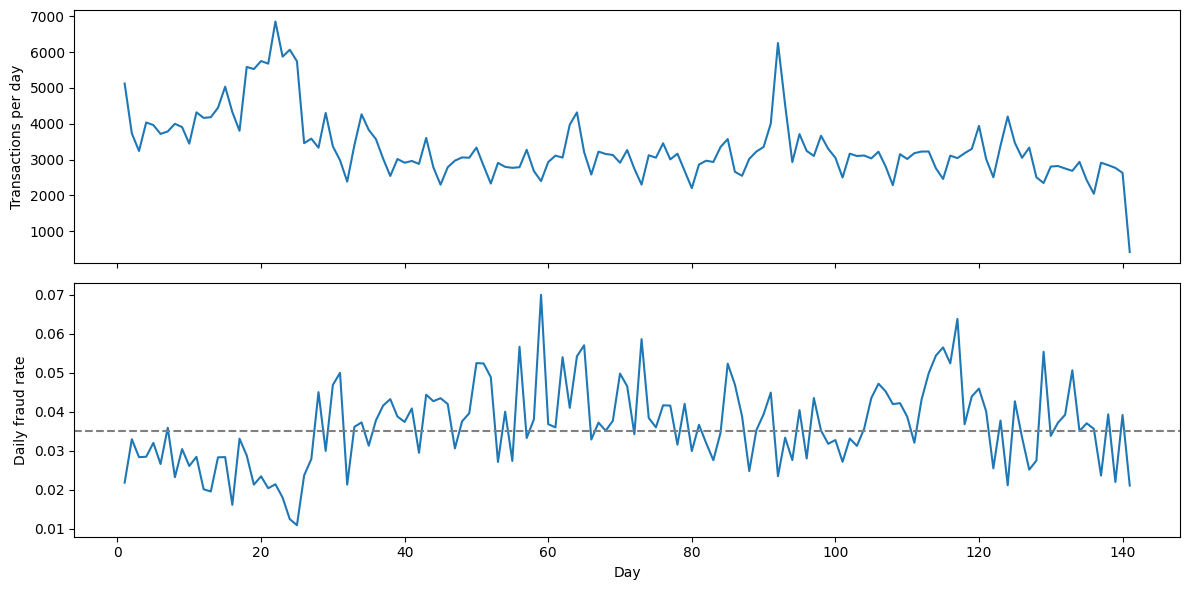

In [10]:
decision_log = []

def log(branch, finding, decision):
    decision_log.append({"branch": branch, "finding": finding, "decision": decision})

# PLAN
# H1: Fraud is heavily imbalanced (< 5%).
# H2: Fraud rate is not constant over time, which would justify the time-based split.

# DO
fraud_rate = train_df["isFraud"].mean()
print(f"Fraud rate: {fraud_rate:.4f} ({train_df['isFraud'].sum():,} of {len(train_df):,})")

train_df["day"] = (train_df["TransactionDT"] // 86400).astype(int)
daily = train_df.groupby("day").agg(n=("isFraud", "size"), fraud_rate=("isFraud", "mean"))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(daily.index, daily["n"])
axes[0].set_ylabel("Transactions per day")
axes[1].plot(daily.index, daily["fraud_rate"])
axes[1].axhline(fraud_rate, linestyle="--", color="gray")
axes[1].set_ylabel("Daily fraud rate")
axes[1].set_xlabel("Day")
plt.tight_layout()
plt.show()

# CHECK and ACT: see the markdown below
log("1. Target and time",
    f"Fraud rate {fraud_rate:.2%} in train and {val_df['isFraud'].mean():.2%} in validation",
    "Use ROC-AUC and PR-AUC rather than accuracy; keep time-based validation")

**Branch 1 check:**

- **H1:** Confirmed. Fraud makes up **3.51%** of training transactions (16,599 of 472,432) and 3.44% of the validation period. With this imbalance, a model that predicts "legit" for everything would be 96.5% accurate, so accuracy is not a useful metric. ROC-AUC and PR-AUC are used instead.
- **H2:** Confirmed. The fraud rate shifts over time. During roughly the first 25 days it mostly stays between 2% and 3.5%, falling to about 1.1% around days 24 to 25. From about day 27 onward it rises to between 3% and 5.5%, with spikes near day 59 (≈ 7%) and day 117 (≈ 6.4%). Days 1 to 25 average <X>% fraud versus <Y>% afterward (relative risk <RR>).

Transaction volume also varies: most days have 2,500 to 3,500 transactions, but days 17 to 25 are much busier (up to ≈ 6,800), and day 92 has a one-day spike (≈ 6,200). The busiest period coincides with the lowest fraud rates, consistent with a surge of ordinary purchases, such as holiday shopping, diluting fraud. The start date of the data was never confirmed, so this interpretation is tentative. The drop on day 141 is an artifact of the time-based split, which cut that day partway through.

**Act:**

1. Evaluate with ROC-AUC and PR-AUC rather than accuracy.
2. Keep the time-based validation split, since fraud patterns differ across periods and a random split would hide this.
3. Do not use raw `TransactionDT` or `day` as model features: test transactions fall outside the training time range. Time effects should enter through cyclical features such as hour of day or day of week (Branch 3).

In [11]:
log("1. Target and time",
    f"Fraud rate {fraud_rate:.2%} in train and {val_df['isFraud'].mean():.2%} in validation; "
    "fraud rate lower in first ~25 days (high-volume period), higher and volatile afterward",
    "Use ROC-AUC and PR-AUC; keep time-based validation; exclude raw TransactionDT/day as features; "
    "explore hour/day-of-week features in Branch 3")

### Branch 2: Data Quality

**Plan**

- **H1:** A large share of columns are mostly missing (over 50% null).
- **H2:** Missingness is structured. Columns, especially the `V` features, go missing together in blocks that share the same null count.
- **H3:** Only a minority of transactions have identity data, and those that do have a different fraud rate.
- **H4:** Whether a value is missing carries signal on its own, so dropping or blindly imputing could throw information away.

Total columns: 434
Complete columns: 20
Columns with missing values > 0%: 414

         n_cols  pct_of_cols
0-10%        92        0.222
10-50%       93        0.225
50-90%      217        0.524
90-100%      12        0.029


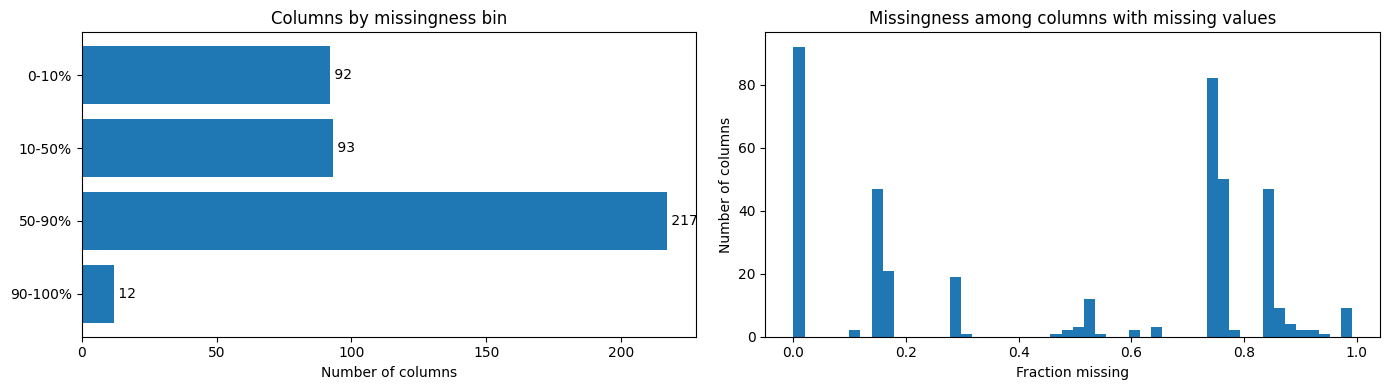

In [12]:
# DO (H1): missingness per column, in non-overlapping bins
missing_all = train_df[original_cols].isna().mean()  # original columns only, excluding engineered features
missing = missing_all[missing_all > 0].sort_values(ascending=False)

bins = [0, 0.1, 0.5, 0.9, 1.0]
labels = ["0-10%", "10-50%", "50-90%", "90-100%"]
missing_bins = pd.cut(missing, bins=bins, labels=labels).value_counts().reindex(labels)

print(f"Total columns: {len(missing_all)}")
print(f"Complete columns: {(missing_all == 0).sum()}")
print(f"Columns with missing values > 0%: {len(missing)}\n")
print(missing_bins.to_frame("n_cols").assign(pct_of_cols=lambda d: (d["n_cols"] / len(missing)).round(3)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Horizontal bar chart of binned counts (labels on the left)
axes[0].barh(missing_bins.index.astype(str), missing_bins.values)
axes[0].invert_yaxis()  # keep 0-10% at the top
axes[0].set_xlabel("Number of columns")
axes[0].set_title("Columns by missingness bin")
for i, v in enumerate(missing_bins.values):
    axes[0].text(v, i, f" {v}", va="center")

# Histogram of raw missing fractions
axes[1].hist(missing, bins=50)
axes[1].set_xlabel("Fraction missing")
axes[1].set_ylabel("Number of columns")
axes[1].set_title("Missingness among columns with missing values")

plt.tight_layout()
plt.show()

**H1 check:** Confirmed.

Of the 434 original columns, only 20 are fully complete, and 414 have at least one missing value. Missingness is heavy: **229 of those 414 columns (55%) are more than half empty**, and 12 are more than 90% empty.

| Missing | Columns | Share of incomplete columns |
|---|---|---|
| 0-10% | 92 | 22.2% |
| 10-50% | 93 | 22.5% |
| 50-90% | 217 | 52.4% |
| 90-100% | 12 | 2.9% |

The histogram shows that missingness is not spread evenly. Instead, columns pile up at a handful of specific levels (around 15%, 28%, 52%, 75-77%, and 85%), with gaps in between. Many columns sharing the exact same missing rate is an early sign of the block structure examined in H2. The large spike around 75-77% likely corresponds to the identity columns, since most transactions have no identity record; this is tested in H3.

**Implication:** with over half of the incomplete columns mostly empty, dropping columns by a simple missingness threshold would remove most of the dataset. Whether a column is worth keeping should depend on whether it carries signal (H4), not on how empty it is. Tree-based models such as LightGBM and XGBoost handle missing values natively, so imputation is not required.

In [13]:
log("2. Data quality (H1)",
    "414 of 434 columns have missing values; 229 (55%) are over 50% missing; "
    "missingness clusters at a few discrete levels",
    "Do not drop by missingness threshold alone; judge columns by signal (H4); "
    "use tree models that handle NaN natively")

In [14]:
# DO (H2): group columns by identical null count to find missingness blocks
null_counts = train_df[original_cols].isna().sum()
blocks = (
    null_counts[null_counts > 0]
    .groupby(null_counts[null_counts > 0])
    .apply(lambda s: list(s.index))
)

block_summary = pd.DataFrame({
    "null_count": blocks.index,
    "pct_missing": (blocks.index / len(train_df)).round(3),
    "n_cols": blocks.apply(len).values,
    "example_cols": blocks.apply(lambda c: c[:6]).values,
}).sort_values("n_cols", ascending=False)

print(f"Distinct missingness blocks: {len(block_summary)}")
print(block_summary.head(15).to_string(index=False))

Distinct missingness blocks: 67
 null_count  pct_missing  n_cols                               example_cols
     362497        0.767      46       [V217, V218, V219, V223, V224, V225]
         97        0.000      43            [V95, V96, V97, V98, V99, V100]
         12        0.000      32       [V279, V280, V284, V285, V286, V287]
     355933        0.753      31       [V167, V168, V172, V173, V176, V177]
     402728        0.852      29       [V138, V139, V140, V141, V142, V143]
      66427        0.141      23             [V12, V13, V14, V15, V16, V17]
      66890        0.142      22             [V53, V54, V55, V56, V57, V58]
      77793        0.165      20             [V75, V76, V77, V78, V79, V80]
     355767        0.753      19       [V169, V170, V171, V174, V175, V180]
     402411        0.852      18       [V322, V323, V324, V325, V326, V327]
     139809        0.296      18             [V35, V36, V37, V38, V39, V40]
     354412        0.750      16       [V220, V221, V222

In [15]:
cols = blocks.iloc[0]  # pick any block
na = train_df[cols].isna()
print(na.eq(na.iloc[:, 0], axis=0).all().all())  # True means identical missing rows

True


In [16]:
multi_blocks = blocks[blocks.apply(len) > 1]

check = pd.DataFrame({
    "null_count": multi_blocks.index,
    "n_cols": multi_blocks.apply(len).values,
    "identical_rows": [
        (lambda na: na.eq(na.iloc[:, 0], axis=0).all().all())(train_df[cols].isna())
        for cols in multi_blocks
    ],
})

print(check["identical_rows"].value_counts())
print(check[~check["identical_rows"]])  # any blocks that only match by count

identical_rows
True    24
Name: count, dtype: int64
Empty DataFrame
Columns: [null_count, n_cols, identical_rows]
Index: []


In [17]:
group_sizes = blocks.apply(len)

print(f"Groups: {len(blocks)}")
print(f"Multi-column groups: {(group_sizes > 1).sum()}")
print(f"Single-column groups: {(group_sizes == 1).sum()}")
print(f"Columns in multi-column groups: {group_sizes[group_sizes > 1].sum()}")
print(f"Columns in single-column groups: {group_sizes[group_sizes == 1].sum()}")
print(f"Total: {group_sizes.sum()}")  # should be 414

Groups: 67
Multi-column groups: 24
Single-column groups: 43
Columns in multi-column groups: 371
Columns in single-column groups: 43
Total: 414


**H2 check:** Confirmed.

A **block** is a group of columns that are always missing together: whenever one column in the block is missing a value for a transaction, every other column in that block is missing a value in that same row.

This pattern is unlikely to be a coincidence. It suggests that missing values come from missing data sources: if a source didn't record anything for a transaction, all of the columns from that source are empty at once.

This matters for feature engineering in two ways:

1. **Missing indicators:** one "is missing" flag per block is enough, since every column in the block would produce the identical flag.
2. **Feature reduction:** columns within the same block (especially the `V` features) are good candidates for keeping only a few representatives instead of all of them.

**How blocks were found:** Of the 434 columns in `train_df`, 414 columns have at least one missing value. We grouped these 414 columns by how many missing values each has, which produced **67 groups**:

- **24 groups contain two or more columns.** These are the blocks. We checked each one and confirmed that its columns are missing in exactly the same rows, not just the same number of rows. Together, these blocks cover **371** columns.
- **43 groups contain a single column.** Each of these columns has its own unique missing pattern that no other column shares, so they are not blocks.

In [18]:
# CHECK (H2): All 24 multi-column missingness blocks share identical null rows,
# not just identical counts. Missingness is structured by data source.
# ACT (H2):
log("2. Data quality (H2)",
    "24 multi-column missingness blocks; all verified to share identical null rows",
    "Treat each block as one unit: consider a single missing-indicator per block "
    "and reduce V columns to a few representatives per block")

In [19]:
# DO (H3): identity coverage and fraud rate with vs without identity

# create a list of all identity columns
id_cols = [c for c in train_df.columns if c.startswith("id_")] + ["DeviceType", "DeviceInfo"]
train_df["has_identity"] = train_df[id_cols].notna().any(axis=1).astype(int)

print(train_df.groupby("has_identity")["isFraud"].agg(n="size", fraud_rate="mean"))

                   n  fraud_rate
has_identity                    
0             351968    0.021309
1             120464    0.075533


**H3 check:** Confirmed, with the effect size revised after accounting for product type (see *H3 revisited* below).

Only **25.5%** of training transactions (120,464 of 472,432) have identity data. These transactions have a fraud rate of **7.55%**, compared with **2.13%** for transactions without identity data. Transactions with identity data account for roughly **55% of all fraud** despite being about a quarter of the data.

Across all transactions, **before accounting for product type**, the relative risk is **3.54** (95% CI 3.44 to 3.65). As the product analysis later in the notebook shows, this figure overstates the effect of identity. Product `W` never has identity data and has the lowest fraud rate, so the no-identity group is almost entirely product `W`, and the 3.54 partly reflects product differences rather than identity itself. When product type is held constant (comparing identity vs no identity within product `C` only), the relative risk is **2.04** (95% CI 1.84 to 2.27). **Use 2.04, not 3.54, as the estimate of the identity effect.**

`has_identity` matches the `[id_01, id_12]` missingness pattern exactly (see H4), so every identity record contains `id_01`. The other identity-related patterns with ratios near 3.5 cover slightly smaller subsets of the same transactions, which confirms they largely reflect this single signal rather than independent ones. Like the 3.54, those ratios are computed before accounting for product type.

**Implication:** keep `has_identity` as a feature. Its signal overlaps heavily with the identity-related missingness patterns, so those patterns can be consolidated rather than each treated as separate evidence. Because identity presence is largely determined by `ProductCD`, the two features should be interpreted together.

In [20]:
log("2. Data quality (H3)",
    "25.5% of transactions have identity data; fraud 7.55% vs 2.13%; ~55% of fraud has identity; "
    "RR 3.54 (CI 3.44-3.65) before accounting for product type, overstated; "
    "within product C, RR 2.04 (CI 1.84-2.27), see H3 revised; has_identity == id_01 presence",
    "Keep has_identity as a feature; treat identity missingness patterns as one consolidated signal; "
    "use RR 2.04 as the identity effect; interpret has_identity together with ProductCD")

### H4: Does missingness itself predict fraud?

**Plan:** For each missingness pattern (one row per block or single column, as identified in H2), compare the fraud rate among transactions where the pattern is missing to the fraud rate where it is present. The **ratio** of the two summarizes the effect:

- **Ratio above 1:** fraud is more common when the columns have values.
- **Ratio below 1:** fraud is more common when the columns are empty.
- **Ratio near 1:** missingness carries no information about fraud.

We treat a ratio above 1.5 or below 0.67 as a meaningful difference (fraud at least 50% more likely on one side).

The analysis is run on two views:

1. **All patterns (67):** every missingness pattern, so nothing is silently excluded.
2. **Excluding extremes (53):** only patterns that are between 5% and 95% missing. The 14 extreme patterns are either almost always filled or almost always empty, so one side of the comparison has few rows and its fraud rate is less stable.

Since the training set has about 470,000 rows, even extreme patterns can have enough rows on both sides to be trustworthy. To judge this directly rather than relying on the 5-95% cutoff alone, each pattern is also flagged as **reliable** if both sides have at least 1,000 rows.

#### How the fraud ratio is calculated

For each missingness pattern, the rows are split into two groups using a True/False mask:

- **Missing group:** rows where the pattern's columns are empty (`is_na = True`)
- **Present group:** rows where the columns have values (`is_na = False`)

Because `isFraud` is coded as 0 (legit) or 1 (fraud), the mean of `isFraud` within a group equals the share of fraud in that group:

$$
\text{fraud rate} = \frac{\text{number of fraud transactions in the group}}{\text{number of transactions in the group}}
$$

This gives two fraud rates:

$$
\text{fraud\_if\_missing} = \frac{\text{fraud rows where } \texttt{is\_na} = \text{True}}{n_{\text{missing}}}
\qquad
\text{fraud\_if\_present} = \frac{\text{fraud rows where } \texttt{is\_na} = \text{False}}{n_{\text{present}}}
$$

The ratio compares them:

$$
\text{ratio} = \frac{\text{fraud\_if\_present}}{\text{fraud\_if\_missing}}
$$

**Worked example** with 10 transactions:

| Row | is_na | isFraud |
|---|---|---|
| 1 | True | 1 |
| 2 | True | 0 |
| 3 | True | 0 |
| 4 | True | 0 |
| 5 | False | 0 |
| 6 | False | 0 |
| 7 | False | 0 |
| 8 | False | 0 |
| 9 | False | 0 |
| 10 | False | 0 |

$$
n_{\text{missing}} = 4, \qquad n_{\text{present}} = 6
$$

$$
\text{fraud\_if\_missing} = \frac{1}{4} = 0.25
\qquad
\text{fraud\_if\_present} = \frac{0}{6} = 0
$$

$$
\text{ratio} = \frac{0}{0.25} = 0
$$

A ratio of 0 means fraud occurs only when the values are missing.

**Interpreting the ratio:**

- **Ratio = 1:** both groups have the same fraud rate, so missingness tells us nothing.
- **Ratio > 1:** fraud is more common when values are present. For example, $\frac{0.06}{0.03} = 2$ means fraud is twice as likely.
- **Ratio < 1:** fraud is more common when values are missing. For example, $\frac{0.03}{0.06} = 0.5$ means fraud is half as likely when present.

These are exact definitions: any ratio other than 1 means the fraud rates differ, even slightly. In real data, ratios almost never equal exactly 1, so we also need a cutoff for how large a difference is worth acting on.

**Cutoff:** we treat a ratio above 1.5 or below 0.67 ($\approx \frac{1}{1.5}$) as a meaningful difference, meaning fraud is at least 50% more likely on one side. Ratios between 0.67 and 1.5 are treated as no meaningful signal. This cutoff is a judgment call about practical importance, not a statistical rule.

In [21]:
# DO (H4): fraud rate when missing vs present, for every missingness pattern
null_counts = train_df[original_cols].isna().sum()
null_counts = null_counts[null_counts > 0]

MIN_ROWS = 1000  # minimum rows on each side for a reliable fraud rate

rows = []
for count, cols in null_counts.groupby(null_counts):
    cols = list(cols.index)
    is_na = train_df[cols[0]].isna()  # block columns share one mask (verified in H2)
    rows.append({
        "n_cols": len(cols),
        "example_cols": cols[:5],
        "pct_missing": is_na.mean(),
        "n_missing": is_na.sum(),
        "n_present": (~is_na).sum(),
        "fraud_if_missing": train_df.loc[is_na, "isFraud"].mean(),
        "fraud_if_present": train_df.loc[~is_na, "isFraud"].mean(),
    })

na_signal_all = pd.DataFrame(rows)
na_signal_all["ratio"] = na_signal_all["fraud_if_present"] / na_signal_all["fraud_if_missing"]
na_signal_all["extreme"] = (na_signal_all["pct_missing"] <= 0.05) | (na_signal_all["pct_missing"] >= 0.95)
na_signal_all["reliable"] = (na_signal_all["n_missing"] >= MIN_ROWS) & (na_signal_all["n_present"] >= MIN_ROWS)
na_signal_all = na_signal_all.sort_values("ratio", ascending=False).reset_index(drop=True)

na_signal_mid = na_signal_all[~na_signal_all["extreme"]]
na_signal_extreme = na_signal_all[na_signal_all["extreme"]]

# Summary comparison
def summarize(df, name):
    return {
        "view": name,
        "patterns": len(df),
        "columns": df["n_cols"].sum(),
        "reliable": df["reliable"].sum(),
        "presence_raises_fraud (ratio > 1.5)": (df["ratio"] > 1.5).sum(),
        "missing_raises_fraud (ratio < 0.67)": (df["ratio"] < 0.67).sum(),
        "no_signal (0.67-1.5)": df["ratio"].between(0.67, 1.5).sum(),
    }

print(pd.DataFrame([
    summarize(na_signal_all, "All patterns"),
    summarize(na_signal_mid, "Excluding extremes (5-95%)"),
    summarize(na_signal_extreme, "Extremes only"),
]).set_index("view").T)

cols_to_show = ["n_cols", "example_cols", "pct_missing", "n_missing", "n_present",
                "fraud_if_missing", "fraud_if_present", "ratio", "reliable"]

print("\n=== All patterns ===")
print(na_signal_all[cols_to_show].round(4).to_string(index=False))

print("\n=== Extreme patterns (excluded from the 5-95% view) ===")
print(na_signal_extreme[cols_to_show].round(4).to_string(index=False))

view                                 All patterns  Excluding extremes (5-95%)  \
patterns                                       67                          53   
columns                                       414                         313   
reliable                                       61                          53   
presence_raises_fraud (ratio > 1.5)            33                          27   
missing_raises_fraud (ratio < 0.67)            14                          11   
no_signal (0.67-1.5)                           20                          15   

view                                 Extremes only  
patterns                                        14  
columns                                        101  
reliable                                         8  
presence_raises_fraud (ratio > 1.5)              6  
missing_raises_fraud (ratio < 0.67)              3  
no_signal (0.67-1.5)                             5  

=== All patterns ===
 n_cols                        example_

#### Statistical test for H4

For each missingness pattern, we test:

- $H_0$: fraud rate when missing = fraud rate when present (relative risk $= 1$)
- $H_1$: the fraud rates differ (relative risk $\neq 1$)

**Test:** chi-square test of independence on the 2×2 table of missing/present by fraud/legit. Because 67 patterns are tested at once, p-values are adjusted with the Benjamini-Hochberg procedure to control the false discovery rate at 5%.

**Effect size:** a 95% confidence interval for the relative risk, computed on the log scale:

$$
\text{CI} = \exp\left(\ln(\text{RR}) \pm 1.96 \cdot \sqrt{\tfrac{1}{a} - \tfrac{1}{n_1} + \tfrac{1}{c} - \tfrac{1}{n_2}}\right)
$$

where $a$ and $c$ are the fraud counts in the present and missing groups, and $n_1$ and $n_2$ are the group sizes.

**Decision rule:** with ~470,000 rows, even tiny differences are statistically significant, so significance alone is not enough. A pattern is classified as:

- **Meaningful** if the adjusted p-value is below 0.05 *and* the entire confidence interval lies above 1.5 or below 0.67
- **Significant but small** if the adjusted p-value is below 0.05 but the interval overlaps the 0.67 to 1.5 range
- **Not significant** if the adjusted p-value is 0.05 or above

In [24]:
# pip install statsmodels

In [25]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

df = na_signal_all.copy()

# Recover fraud counts in each group from rates and group sizes
df["fraud_missing"] = (df["fraud_if_missing"] * df["n_missing"]).round().astype(int)
df["fraud_present"] = (df["fraud_if_present"] * df["n_present"]).round().astype(int)

p_values, ci_low, ci_high = [], [], []
for _, r in df.iterrows():
    a, n1 = r["fraud_present"], r["n_present"]   # present group
    c, n2 = r["fraud_missing"], r["n_missing"]   # missing group

    # Chi-square test of independence on the 2x2 table
    table = [[a, n1 - a], [c, n2 - c]]
    p_values.append(chi2_contingency(table)[1])

    # 95% CI for the relative risk (log method); add 0.5 if a cell is zero
    if min(a, c, n1 - a, n2 - c) == 0:
        a, c, n1, n2 = a + 0.5, c + 0.5, n1 + 1, n2 + 1
    log_rr = np.log((a / n1) / (c / n2))
    se = np.sqrt(1 / a - 1 / n1 + 1 / c - 1 / n2)
    ci_low.append(np.exp(log_rr - 1.96 * se))
    ci_high.append(np.exp(log_rr + 1.96 * se))

df["p_value"] = p_values
df["p_adj"] = multipletests(df["p_value"], method="fdr_bh")[1]  # Benjamini-Hochberg
df["ci_low"], df["ci_high"] = ci_low, ci_high

def classify(r):
    if r["p_adj"] >= 0.05:
        return "not significant"
    if r["ci_low"] > 1.5:
        return "meaningful: presence raises fraud"
    if r["ci_high"] < 0.67:
        return "meaningful: missing raises fraud"
    return "significant but small"

df["verdict"] = df.apply(classify, axis=1)

print(df["verdict"].value_counts())
print(df[["n_cols", "example_cols", "n_missing", "n_present", "ratio",
          "ci_low", "ci_high", "p_adj", "verdict"]].round(4).to_string(index=False))

verdict
meaningful: presence raises fraud    33
significant but small                19
meaningful: missing raises fraud      9
not significant                       6
Name: count, dtype: int64
 n_cols                        example_cols  n_missing  n_present  ratio  ci_low  ci_high  p_adj                           verdict
      1                                [D7]     442488      29944 5.4660  5.2928   5.6449 0.0000 meaningful: presence raises fraud
      1                               [D12]     419729      52703 4.5001  4.3656   4.6388 0.0000 meaningful: presence raises fraud
      1                               [D14]     422596      49836 4.4490  4.3147   4.5875 0.0000 meaningful: presence raises fraud
      1                               [D13]     423459      48973 4.0751  3.9498   4.2044 0.0000 meaningful: presence raises fraud
      1                                [D6]     413949      58483 4.0394  3.9183   4.1641 0.0000 meaningful: presence raises fraud
      4             

**H4 check:** Confirmed.

Of 67 missingness patterns, **42 show a meaningful difference** in fraud rate (adjusted p < 0.05 and the full 95% confidence interval beyond 1.5 or 0.67): in 33, fraud is more common when values are present, and in 9 it is more common when values are missing. A further 19 are statistically significant but small, and 6 are not significant.

**Key findings:**

- **The strongest presence signals** are `D6` to `D14` (up to 5.5x for `D7`), despite these columns being 87% to 94% missing.
- **The identity columns** (`id_01` to `id_20`, `DeviceType`, and the V167, V169, V217, and V220 blocks) all show a ratio of about 3.5 at roughly 75% missing. These likely reflect a single underlying signal, whether the transaction has an identity record, rather than many independent ones.
- **The strongest missingness signal** is `addr1`/`addr2`: fraud is 11.4% when the address is missing versus 2.5% when present (ratio 0.22). The `M` flags, `dist1`, and the `D11`/`V1` to `V4` block also show meaningful effects in this direction.
- **All 6 non-significant patterns** have very small missing groups (12 to 936 rows). For example, the V279 block has an extreme ratio of 0.21, but with only 12 missing rows its confidence interval (0.06 to 0.75) is too wide to support a conclusion.

**Implications:**

1. Missingness is informative and should be preserved, either by leaving NaNs for tree-based models or by adding one missing-indicator per block.
2. Columns should not be dropped for high missingness alone: `D7` (94% missing) and `id_24` (99% missing) both carry meaningful signal.
3. The identity-related patterns are largely redundant; a single `has_identity` flag may capture most of their missingness signal (tested in H3).

In [26]:
log("2. Data quality (H4)",
    "42 of 67 missingness patterns meaningfully shift fraud rate (33 presence, 9 missing); "
    "strongest: D7 present 5.5x, addr missing 0.22x; identity patterns likely redundant",
    "Preserve missingness (NaN for tree models or one indicator per block); "
    "never drop columns by missingness alone; consolidate identity patterns via has_identity")

#### H4 visualizations

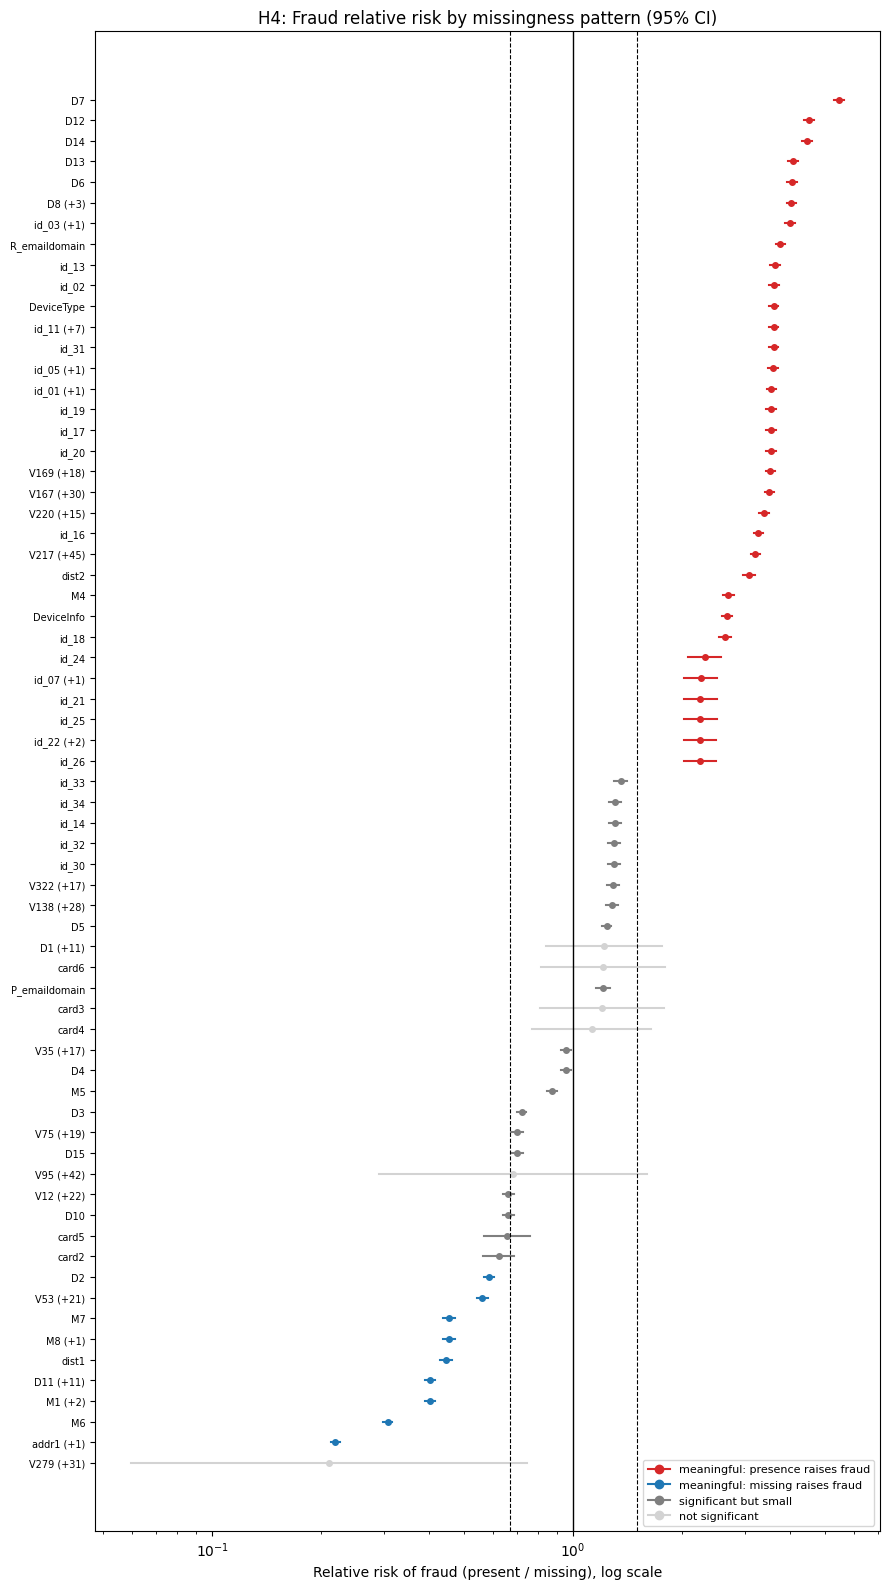

In [27]:
# Forest plot: relative risk with 95% CI per missingness pattern
plot_df = df.sort_values("ratio").reset_index(drop=True)
plot_df["label"] = plot_df.apply(
    lambda r: f"{r['example_cols'][0]}" + (f" (+{r['n_cols'] - 1})" if r["n_cols"] > 1 else ""), axis=1
)

colors = {
    "meaningful: presence raises fraud": "tab:red",
    "meaningful: missing raises fraud": "tab:blue",
    "significant but small": "tab:gray",
    "not significant": "lightgray",
}

fig, ax = plt.subplots(figsize=(9, 16))
for i, r in plot_df.iterrows():
    c = colors[r["verdict"]]
    ax.plot([r["ci_low"], r["ci_high"]], [i, i], color=c, linewidth=1.5)
    ax.plot(r["ratio"], i, "o", color=c, markersize=4)

ax.axvline(1, color="black", linewidth=1)
ax.axvline(1.5, color="black", linestyle="--", linewidth=0.8)
ax.axvline(0.67, color="black", linestyle="--", linewidth=0.8)
ax.set_xscale("log")  # ratios of 2 and 0.5 sit equally far from 1
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["label"], fontsize=7)
ax.set_xlabel("Relative risk of fraud (present / missing), log scale")
ax.set_title("H4: Fraud relative risk by missingness pattern (95% CI)")

for verdict, c in colors.items():
    ax.plot([], [], "o-", color=c, label=verdict)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

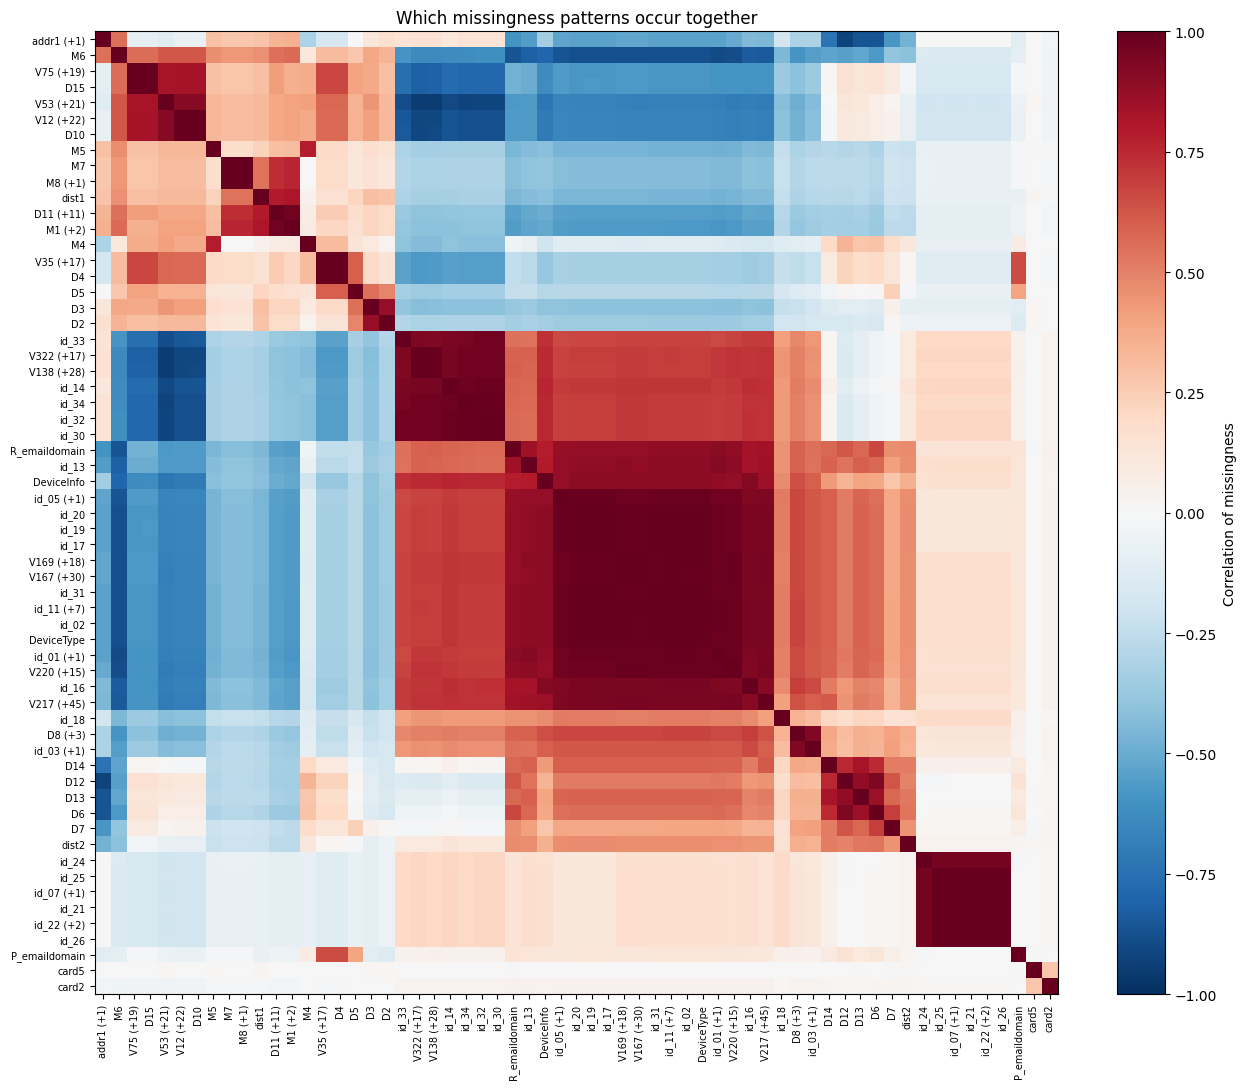

In [28]:
from scipy.cluster.hierarchy import linkage, leaves_list

# Missingness indicator heatmap: one column per pattern (excluding tiny groups)
sub = df[df["n_missing"] >= 1000]
rep_cols = [r["example_cols"][0] for _, r in sub.iterrows()]
labels = sub.apply(
    lambda r: r["example_cols"][0] + (f" (+{r['n_cols'] - 1})" if r["n_cols"] > 1 else ""), axis=1
).tolist()

na_matrix = train_df[rep_cols].isna().astype(np.int8)
na_corr = na_matrix.corr()

# Reorder so correlated patterns sit next to each other
order = leaves_list(linkage(na_corr, method="average"))
na_corr = na_corr.iloc[order, order]
ordered_labels = [labels[i] for i in order]

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(na_corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(ordered_labels)))
ax.set_yticks(range(len(ordered_labels)))
ax.set_xticklabels(ordered_labels, rotation=90, fontsize=7)
ax.set_yticklabels(ordered_labels, fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, label="Correlation of missingness")
ax.set_title("Which missingness patterns occur together")
plt.tight_layout()
plt.show()

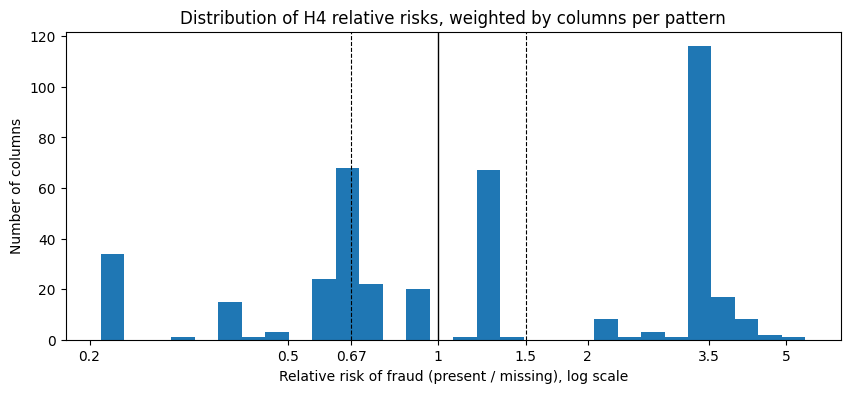

In [29]:
# Histogram of relative risks across all 67 patterns
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log(df["ratio"]), bins=30, weights=df["n_cols"])  # weight by columns so big blocks count more
ax.axvline(0, color="black", linewidth=1)
ax.axvline(np.log(1.5), color="black", linestyle="--", linewidth=0.8)
ax.axvline(np.log(0.67), color="black", linestyle="--", linewidth=0.8)
ticks = [0.2, 0.5, 0.67, 1, 1.5, 2, 3.5, 5]
ax.set_xticks(np.log(ticks))
ax.set_xticklabels(ticks)
ax.set_xlabel("Relative risk of fraud (present / missing), log scale")
ax.set_ylabel("Number of columns")
ax.set_title("Distribution of H4 relative risks, weighted by columns per pattern")
plt.show()

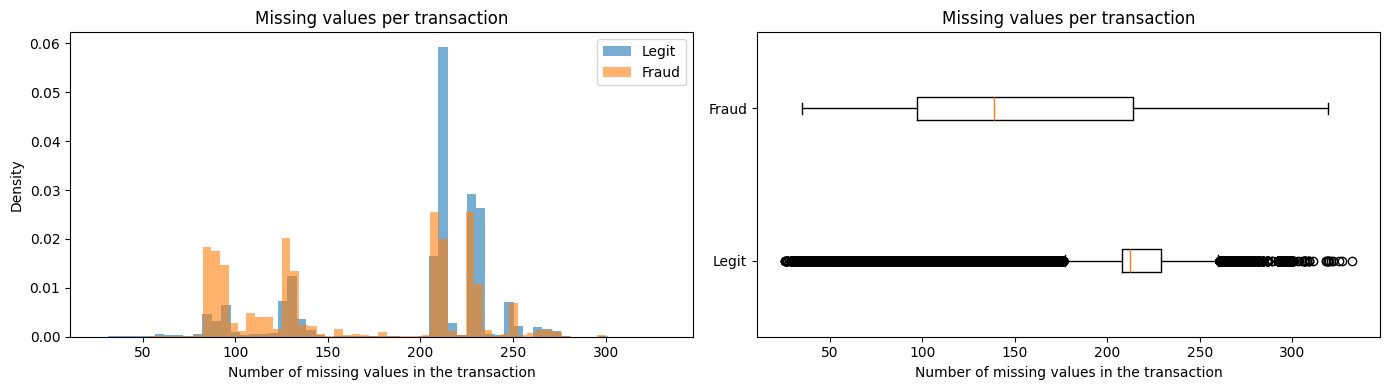

          legit    fraud
count  455833.0  16599.0
mean      196.8    162.9
std        49.2     60.1
min        26.0     35.0
25%       208.0     97.0
50%       212.0    139.0
75%       229.0    214.0
max       332.0    319.0


In [30]:
# Missing values per transaction: fraud vs legit
row_missing = train_df[original_cols].isna().sum(axis=1)
legit = row_missing[train_df["isFraud"] == 0]
fraud = row_missing[train_df["isFraud"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(legit, bins=60, alpha=0.6, density=True, label="Legit")
axes[0].hist(fraud, bins=60, alpha=0.6, density=True, label="Fraud")
axes[0].set_xlabel("Number of missing values in the transaction")
axes[0].set_ylabel("Density")
axes[0].set_title("Missing values per transaction")
axes[0].legend()

axes[1].boxplot([legit, fraud], orientation="horizontal")
axes[1].set_yticks([1, 2])
axes[1].set_yticklabels(["Legit", "Fraud"])
axes[1].set_xlabel("Number of missing values in the transaction")
axes[1].set_title("Missing values per transaction")

plt.tight_layout()
plt.show()

print(pd.DataFrame({"legit": legit.describe(), "fraud": fraud.describe()}).round(1))

**Missing values per transaction:** Fraudulent transactions are more complete than legitimate ones. The median fraud transaction is missing 139 of 434 fields (32%), compared with 212 (49%) for legitimate transactions.

Legitimate transactions are also highly uniform: half fall between 208 and 229 missing values, suggesting most share a common profile (typically no identity record). Fraudulent transactions vary much more, with the middle half ranging from 97 to 214, and a quarter missing fewer than 97 fields.

This is consistent with the pattern-level results: the patterns where presence raises fraud (the identity cluster and large `V` blocks) cover far more columns than those where missingness raises fraud (such as `addr1`/`addr2`), so their effect dominates the per-transaction total.

### H5: Transactions form distinct missingness profiles

**Plan**

- **H5a:** Although there are many possible combinations of missing column groups, transactions concentrate into a small number of recurring missingness profiles.
- **H5b:** These profiles group into a few broad transaction types that can be recovered by clustering, without using `ProductCD` or `has_identity`.
- **H5c:** Fraud rates differ substantially between these transaction types.

#### Missingness profiles

To study how missing data is structured across transactions, each transaction is described by its **missingness profile**: a record of which groups of columns it is missing.

**Building the profile matrix (`X_prof`):**

- **Rows:** one per transaction (472,432).
- **Columns:** one per missingness pattern (67), taken from the H4 analysis.
- **Values:** `1` if the transaction is missing that pattern, `0` if the values are present.

Because columns within a block are always missing together (confirmed in H2), a single representative column stands in for each block. For example, `na_V169` represents all 19 columns in its `V` block: if a transaction is missing `V169`, it is missing the other 18 as well. The 20 fully complete columns are excluded, since they are never missing and cannot distinguish one transaction from another.

**Example** with 3 patterns instead of 67:

| Transaction | `na_D7` | `na_id_11` | `na_M4` | Profile |
|---|---|---|---|---|
| A | 1 | 1 | 0 | `110` |
| B | 1 | 1 | 0 | `110` |
| C | 0 | 0 | 1 | `001` |

Transactions A and B share the same profile (missing `D7` and identity data, with `M4` present), so they are grouped together. Transaction C has a different profile.

**Counting profiles:** each transaction's 67 values are combined into a single profile key, and transactions are grouped by that key to count how many share each profile and what share of them are fraud. The training data contains **11,341 distinct profiles**, but they are highly concentrated: the **118 most common profiles cover 80%** of transactions, and the top 15 alone cover 45%.

**Why it matters:** the concentration shows that missingness reflects a small number of recurring transaction types rather than random gaps. Since fraud rates differ across profiles (0.45% to 4.1% among the 15 most common), profile type is a candidate feature. However, the long tail of rare profiles means new, unseen profiles are likely in later data, so broader groupings (such as the clusters below) are safer to use than exact profiles.

The profile matrix `X_prof` is also the input for the clustering and PCA that follow, so each point in those plots is a single transaction positioned by its missingness profile.

In [31]:
# One indicator per missingness pattern (1 = missing), from the H4 table
pattern_rep = {r["example_cols"][0]: f"na_{r['example_cols'][0]}" for _, r in df.iterrows()}
X_prof = pd.DataFrame(
    {new: train_df[old].isna().astype(np.int8) for old, new in pattern_rep.items()},
    index=train_df.index,
)

# Count exact missingness profiles
profile_key = X_prof.astype(str).agg("".join, axis=1)
profiles = (
    pd.DataFrame({"profile": profile_key, "isFraud": train_df["isFraud"]})
    .groupby("profile")["isFraud"]
    .agg(n="size", fraud_rate="mean")
    .sort_values("n", ascending=False)
)
profiles["cum_share"] = profiles["n"].cumsum() / profiles["n"].sum()

print(f"Distinct missingness profiles: {len(profiles):,}")
print(f"Profiles covering 80% of transactions: {(profiles['cum_share'] < 0.8).sum() + 1}")
print(profiles.head(15).round(4))

Distinct missingness profiles: 11,341
Profiles covering 80% of transactions: 118
                                                        n  fraud_rate  \
profile                                                                 
11111111111111111111111111111111111111110000000...  32043      0.0052   
11111111111111111111111101111111111111110000000...  28683      0.0409   
11111111111111111111111101111111111111110000000...  26674      0.0402   
11111111111111111111111111111111111111110000000...  22528      0.0048   
11111111111111111111111101111111111111110000000...  15316      0.0324   
11111111111111111111111101111111111111111000000...  12209      0.0207   
11111111111111111111111101111111111111111000000...  10343      0.0188   
11111111111111111111111101111111111111111000000...   9680      0.0169   
11111111111111111111111111111111111111110000000...   9064      0.0045   
11111111111111111111111111111111111111111001001...   8809      0.0086   
1111111000000000000000011011111110000000100

In [32]:
# Rows around where cum_share crosses 80%
cross = (profiles["cum_share"] < 0.8).sum()  # index of the profile that crosses 80%
view = profiles.reset_index(drop=True)
view.index = view.index + 1  # number profiles from 1 instead of 0
view.index.name = "rank"

print(view.loc[cross - 2 : cross + 3, ["n", "fraud_rate", "cum_share"]].round(4))

        n  fraud_rate  cum_share
rank                            
115   471      0.0340     0.7973
116   471      0.0297     0.7983
117   458      0.0087     0.7993
118   454      0.0573     0.8002
119   453      0.0751     0.8012
120   450      0.0000     0.8022


In [33]:
# How many profiles it takes to reach each coverage level
for target in [0.25, 0.5, 0.75, 0.8, 0.9, 0.95, 0.99, 1.0]:
    k = (profiles["cum_share"] < target).sum() + 1
    print(f"{target:>5.0%} of transactions covered by the top {min(k, len(profiles)):,} profiles")

# How rare the tail is
print(f"\nProfiles shared by only 1 transaction: {(profiles['n'] == 1).sum():,}")
print(f"Profiles shared by fewer than 10:      {(profiles['n'] < 10).sum():,}")

  25% of transactions covered by the top 5 profiles
  50% of transactions covered by the top 19 profiles
  75% of transactions covered by the top 80 profiles
  80% of transactions covered by the top 118 profiles
  90% of transactions covered by the top 378 profiles
  95% of transactions covered by the top 1,137 profiles
  99% of transactions covered by the top 6,617 profiles
 100% of transactions covered by the top 11,341 profiles

Profiles shared by only 1 transaction: 5,959
Profiles shared by fewer than 10:      9,888


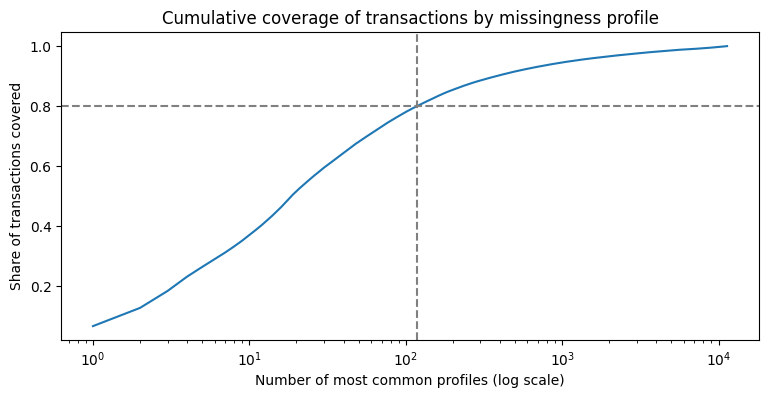

In [34]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, len(profiles) + 1), profiles["cum_share"])
plt.axhline(0.8, color="gray", linestyle="--")
plt.axvline(cross + 1, color="gray", linestyle="--")
plt.xscale("log")
plt.xlabel("Number of most common profiles (log scale)")
plt.ylabel("Share of transactions covered")
plt.title("Cumulative coverage of transactions by missingness profile")
plt.show()

#### Rare vs common profiles

In [35]:
top_profiles = profiles.index[: cross + 1]
is_common = profile_key.isin(top_profiles)

print(train_df.groupby(is_common.map({True: "Top 118 profiles", False: "Rare tail"}))["isFraud"]
      .agg(n="size", fraud_rate="mean").round(4))

                       n  fraud_rate
Rare tail          94373      0.0711
Top 118 profiles  378059      0.0262


In [36]:
tail_label = is_common.map({True: "Top 118", False: "Rare tail"}).rename("profile_group")

# Product mix of each group
print(pd.crosstab(tail_label, train_df["ProductCD"], normalize="index").round(3))

# Fraud rate by group within each product
train_df.groupby([train_df["ProductCD"], tail_label])["isFraud"]\
      .agg(n="size", fraud_rate="mean").unstack().round(4)

ProductCD          C      H      R      S      W
profile_group                                   
Rare tail      0.333  0.121  0.138  0.081  0.327
Top 118        0.066  0.048  0.051  0.001  0.834


n         fraud_rate        
profile_group Rare tail Top 118  Rare tail Top 118
ProductCD                                         
C                 31451   24959     0.1458  0.0724
H                 11396   18295     0.0448  0.0473
R                 13066   19137     0.0321  0.0391
S                  7621     506     0.0631  0.0435
W                 30839  315162     0.0232  0.0204

**Defining the rare tail:** each transaction is assigned to one of two groups based on how common its missingness profile is.

- **Common profiles (Top 118):** transactions whose profile is one of the 118 most frequent profiles. These 118 profiles together cover 80% of transactions (378,059).
- **Rare tail:** all other transactions (94,373, or 20%). Their profiles are spread across the remaining 11,223 profiles, each shared by relatively few transactions. These are transactions missing an unusual combination of column groups.

The cutoff follows from the 80% coverage threshold rather than a natural break in the data. In the table below, the relative risk is the rare-tail fraud rate divided by the common-profile fraud rate, so values above 1 mean a rare profile is associated with more fraud.

**Controlling for product type:** The rare tail is heavily weighted toward product `C` (33.3% of the tail vs 6.6% of common profiles) and away from product `W` (32.7% vs 83.4%). Because `C` has the highest fraud rate and `W` the lowest, much of the overall gap (7.11% vs 2.62%) reflects product mix.

| Product | Rare tail: n | Rare tail: fraud | Top 118: n | Top 118: fraud | Relative risk |
|---|---|---|---|---|---|
| C | 31,451 | 14.58% | 24,959 | 7.24% | 2.01 |
| H | 11,396 | 4.48% | 18,295 | 4.73% | 0.95 |
| R | 13,066 | 3.21% | 19,137 | 3.91% | 0.82 |
| S | 7,621 | 6.31% | 506 | 4.35% | 1.45* |
| W | 30,839 | 2.32% | 315,162 | 2.04% | 1.14 |

\*Based on only 506 common-profile transactions (about 22 fraud cases), so not reliable.

Within products, a rare profile is associated with substantially higher fraud only for product `C` (relative risk ≈ 2.0), with a small effect for `W` and none for `H` or `R`. Profile rarity is therefore not a general fraud signal. Within product `C`, it may also overlap with identity presence, which showed a similar relative risk (2.04).

**Implication:** a "rare profile" feature may help, mainly for product `C`. Tree-based models can capture this product-specific interaction directly if both `ProductCD` and the rarity flag are provided. Rarity must be defined using training data only and then applied unchanged to validation and test data.

#### Clustering

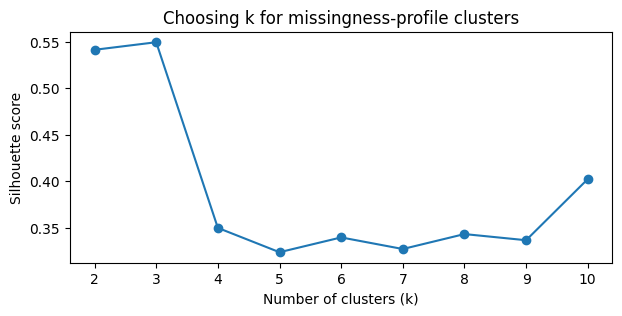

Best k by silhouette: 3


In [37]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

sample_idx = X_prof.sample(50_000, random_state=42).index
X_s = X_prof.loc[sample_idx]

scores = {}
for k in range(2, 11):
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=5, batch_size=4096).fit(X_s)
    scores[k] = silhouette_score(X_s, km.labels_, sample_size=10_000, random_state=42)

plt.figure(figsize=(7, 3))
plt.plot(list(scores), list(scores.values()), "o-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Choosing k for missingness-profile clusters")
plt.show()

best_k = max(scores, key=scores.get)
print(f"Best k by silhouette: {best_k}")

**Choosing k:** The silhouette score peaks at k = 3 (≈ 0.55), with k = 2 nearly tied (≈ 0.54). Scores drop sharply at k = 4 (≈ 0.35) and stay low through k = 10, indicating that the missingness profiles form about three well-separated groups and that additional clusters split natural groups apart. The minor rise at k = 7 is likely sampling noise. We proceed with **k = 3**.

In [38]:
km = MiniBatchKMeans(n_clusters=best_k, random_state=42, n_init=5, batch_size=4096).fit(X_prof)
train_df["na_cluster"] = km.labels_

summary = train_df.groupby("na_cluster").agg(
    n=("isFraud", "size"),
    fraud_rate=("isFraud", "mean"),
    has_identity=("has_identity", "mean"),
)
# Average number of missing patterns (out of 67) per transaction in each cluster
summary["avg_missing_patterns"] = X_prof.sum(axis=1).groupby(train_df["na_cluster"]).mean()
summary["share"] = summary["n"] / summary["n"].sum()
print(summary.round(3))

# Which product types fall in each cluster (checks the ProductCD question from H3)
print(pd.crosstab(train_df["na_cluster"], train_df["ProductCD"], normalize="index").round(2))

                 n  fraud_rate  has_identity  avg_missing_patterns  share
na_cluster                                                               
0           354147       0.021         0.006                44.005  0.750
1            68432       0.044         1.000                30.978  0.145
2            49853       0.120         1.000                27.303  0.106
ProductCD      C     H     R     S     W
na_cluster                              
0           0.02  0.00  0.00  0.00  0.98
1           0.00  0.43  0.46  0.12  0.00
2           1.00  0.00  0.00  0.00  0.00


**Clustering result:** With k = 3, transactions separate into three groups, even though neither `ProductCD` nor `has_identity` was used in the clustering:

| Cluster | Share | Description | Has identity | Fraud rate |
|---|---|---|---|---|
| 0 | 75.0% | All transactions without identity data (98% product `W`), plus ~2,200 identity transactions with similar profiles | 0.6% | 2.1% |
| 1 | 14.5% | Identity transactions for products `H`, `R`, `S` | 100% | 4.4% |
| 2 | 10.6% | Identity transactions for product `C` | 100% | 12.0% |

The clustering separates transactions first by whether they have identity data, and then, among those with identity data, by whether the product is `C`. Because product `W` never has identity data, the no-identity cluster is almost entirely product `W`. This shows that the missingness structure examined in H1 to H4 is largely driven by product type and identity collection together.

#### H3 revisited: product type as a confounder

Because the clusters line up so closely with product type, the H3 identity comparison is repeated within each product.

In [39]:
print(pd.crosstab(train_df["ProductCD"], train_df["has_identity"],
                  values=train_df["isFraud"], aggfunc="mean").round(4))
print(pd.crosstab(train_df["ProductCD"], train_df["has_identity"]))

has_identity       0       1
ProductCD                   
C             0.0585  0.1195
H             0.0297  0.0464
R             0.0233  0.0364
S             0.0385  0.0620
W             0.0207     NaN
has_identity       0      1
ProductCD                  
C               5711  50699
H                101  29590
R                129  32074
S                 26   8101
W             346001      0


In [40]:
c = train_df[train_df["ProductCD"] == "C"]
a, n1 = c.loc[c["has_identity"] == 1, "isFraud"].sum(), (c["has_identity"] == 1).sum()
b, n2 = c.loc[c["has_identity"] == 0, "isFraud"].sum(), (c["has_identity"] == 0).sum()

rr = (a / n1) / (b / n2)
se = np.sqrt(1 / a - 1 / n1 + 1 / b - 1 / n2)
print(f"RR = {rr:.2f}, 95% CI = {np.exp(np.log(rr) - 1.96 * se):.2f} to {np.exp(np.log(rr) + 1.96 * se):.2f}")

RR = 2.04, 95% CI = 1.84 to 2.27


**Relative risk (RR)** compares the fraud rate in one group to the fraud rate in another:

$$
\text{RR} = \frac{\text{fraud rate with identity}}{\text{fraud rate without identity}}
$$

An RR of 1 means both groups have the same fraud rate, an RR of 2 means fraud is twice as likely in the identity group, and an RR below 1 means it is less likely. RR measures an association, not a cause.

| Product | No identity: n | No identity: fraud | Identity: n | Identity: fraud | RR |
|---|---|---|---|---|---|
| C | 5,711 | 5.85% | 50,699 | 11.95% | 2.04 |
| H | 101 | 2.97% | 29,590 | 4.64% | 1.56* |
| R | 129 | 2.33% | 32,074 | 3.64% | 1.56* |
| S | 26 | 3.85% | 8,101 | 6.20% | 1.61* |
| W | 346,001 | 2.07% | 0 | n/a | n/a |

\*Based on 26 to 129 no-identity transactions (only a few fraud cases each), so not reliable.

Product `W` never has identity data, and products `H`, `R`, and `S` almost always do. As a result, the overall H3 comparison (7.55% vs 2.13%, relative risk 3.54) mainly contrasts product `W` against the other products rather than identity against no identity.

Product `C` is the only product with enough transactions on both sides for a fair comparison. Within `C`, transactions with identity data have a fraud rate of 11.95% versus 5.85% without, a relative risk of **2.04** (95% CI 1.84 to 2.27). The interval lies entirely above 1.5, so the effect is both statistically reliable and meaningful by the H4 cutoff.

**Comparing the two relative risks:**

| Comparison | RR | What it measures |
|---|---|---|
| All transactions, identity vs no identity | 3.54 | Identity effect and product effect combined |
| Product `C` only, identity vs no identity | 2.04 | Identity effect with product held constant |

The gap between 3.54 and 2.04 is largely the product effect: the no-identity group is dominated by product `W`, which has the lowest fraud rate.

**Revised H3 conclusion:** identity presence is associated with about **twice** the fraud risk once product type is accounted for, not the unadjusted 3.5x. This estimate comes from product `C` alone, since it cannot be measured for `W` (no identity data) and the no-identity groups for `H`, `R`, and `S` are too small. `has_identity` is almost entirely determined by `ProductCD` except within product `C`, so the two features overlap heavily.

**Implication:** `ProductCD` should be treated as a primary feature. Missingness indicators and `has_identity` are partly redundant with it; `has_identity` still adds information, mainly within product `C`, and tree-based models can capture this interaction directly.

In [41]:
log("2. Data quality (H3 revised)",
    "Product W (73% of data) never has identity; H/R/S almost always do. Within product C, "
    "identity RR = 2.04 (95% CI 1.84-2.27) vs 3.54 (which was the RR before accounting for product type)",
    "Treat ProductCD as primary feature; keep has_identity (informative mainly within C); "
    "interpret identity-related missingness signals as partly product effects")

#### PCA projection

Variance explained by 2 components: 67.2%


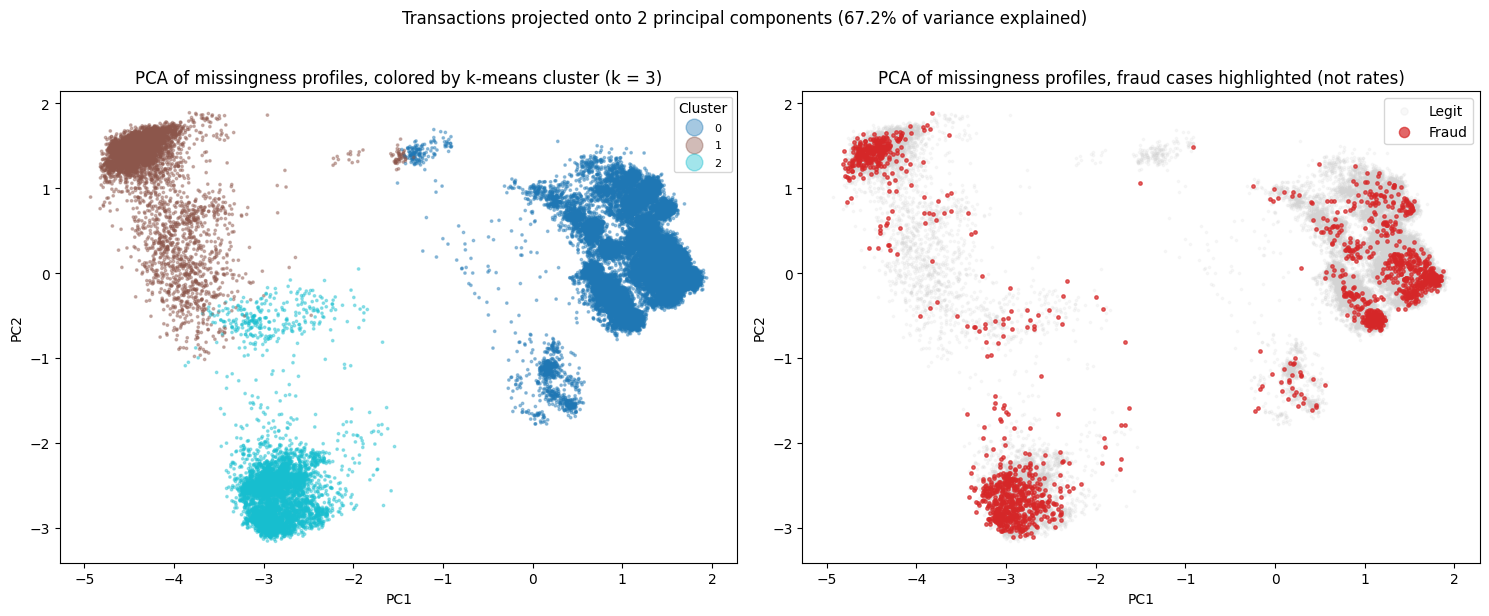

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_prof.loc[sample_idx])
var_explained = pca.explained_variance_ratio_.sum()
print(f"Variance explained by 2 components: {var_explained:.1%}")

# Small jitter: binary profiles land on identical points otherwise
rng = np.random.default_rng(42)
coords_j = coords + rng.normal(0, 0.05, coords.shape)

s = train_df.loc[sample_idx]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: colored by k-means cluster
sc = axes[0].scatter(coords_j[:, 0], coords_j[:, 1], c=s["na_cluster"], cmap="tab10", s=3, alpha=0.4)
axes[0].set_title("PCA of missingness profiles, colored by k-means cluster (k = 3)")
axes[0].legend(*sc.legend_elements(), title="Cluster", fontsize=8, markerscale=2)

# Right: fraud drawn on top of legit
is_f = s["isFraud"].values == 1
axes[1].scatter(coords_j[~is_f, 0], coords_j[~is_f, 1], s=3, alpha=0.15, color="lightgray", label="Legit")
axes[1].scatter(coords_j[is_f, 0], coords_j[is_f, 1], s=6, alpha=0.7, color="tab:red", label="Fraud")
axes[1].set_title("PCA of missingness profiles, fraud cases highlighted (not rates)")
axes[1].legend(markerscale=3)

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

fig.suptitle(f"Transactions projected onto 2 principal components "
             f"({var_explained:.1%} of variance explained)", y=1.02)
plt.tight_layout()
plt.show()

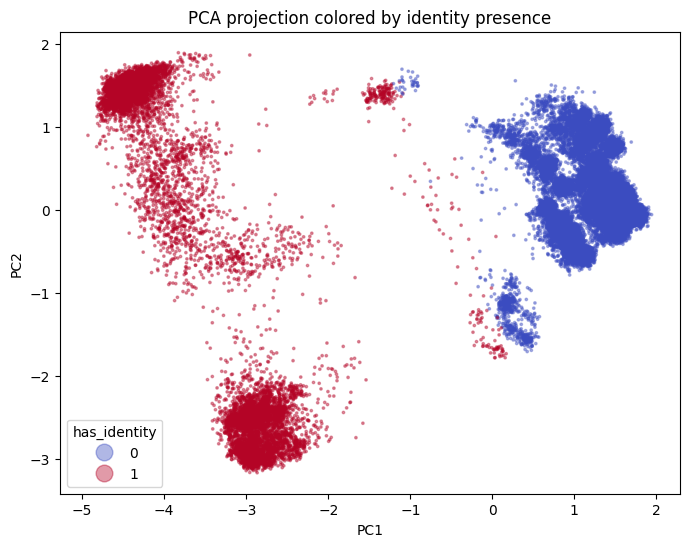

In [43]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(coords_j[:, 0], coords_j[:, 1], c=s["has_identity"], cmap="coolwarm", s=3, alpha=0.4)
ax.legend(*sc.legend_elements(), title="has_identity", markerscale=2)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA projection colored by identity presence")
plt.show()

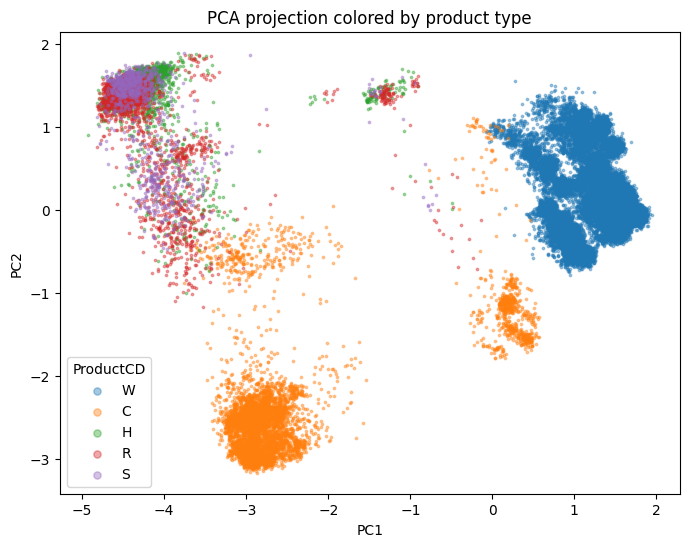

In [44]:
fig, ax = plt.subplots(figsize=(8, 6))
for prod_code in ["W", "C", "H", "R", "S"]:
    m = s["ProductCD"].values == prod_code
    ax.scatter(coords_j[m, 0], coords_j[m, 1], s=3, alpha=0.4, label=prod_code)
ax.legend(title="ProductCD", markerscale=3)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA projection colored by product type")
plt.show()

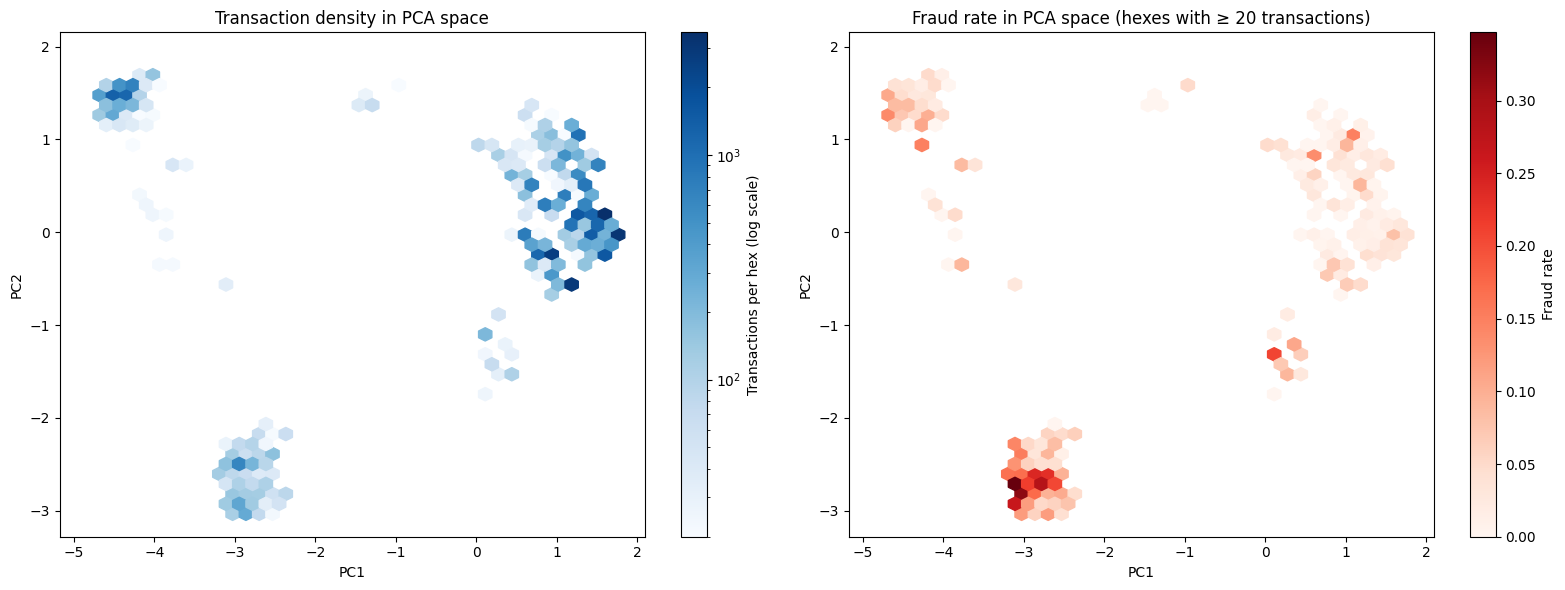

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

hb0 = axes[0].hexbin(coords[:, 0], coords[:, 1], gridsize=40, mincnt=20, bins="log", cmap="Blues")
fig.colorbar(hb0, ax=axes[0], label="Transactions per hex (log scale)")
axes[0].set_title("Transaction density in PCA space")

hb1 = axes[1].hexbin(coords[:, 0], coords[:, 1], C=s["isFraud"].values,
                     reduce_C_function=np.mean, gridsize=40, mincnt=20, cmap="Reds")
fig.colorbar(hb1, ax=axes[1], label="Fraud rate")
axes[1].set_title("Fraud rate in PCA space (hexes with ≥ 20 transactions)")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

The profile matrix is projected onto two principal components, which explain **67.2%** of the variance, so the 2D view captures most of the structure. Each point is one transaction, positioned by its missingness profile.

- **PC1** separates transactions with identity data from those without.
- **PC2** separates product `C` from products `H`, `R`, and `S`.
- Product `W` forms several distinct lobes, reflecting sub-types within `W` driven by non-identity patterns such as the `M` flags and `D` columns.
- Product `C` without identity forms its own small island, separate from the main product `C` cluster.
- Products `H`, `R`, and `S` overlap almost completely, meaning their missingness profiles are nearly identical.

The fraud-highlighted scatter shows where fraud cases occur, but it overstates fraud in dense regions because fraud points are drawn on top. The hexbin map corrects this by coloring each area by its actual fraud rate: the product `C` identity cluster is genuinely high risk (core areas reach 25% to 30% fraud), while most of product `W` is low (0% to 5%), with only a few moderately elevated areas. Isolated dark hexes near the 20-transaction minimum are noisy and should be treated as leads rather than findings.

#### Fraud rate vs fraud count by product

In [46]:
prod = train_df.groupby("ProductCD")["isFraud"].agg(n="size", fraud_cases="sum", fraud_rate="mean")
prod["share_of_all_fraud"] = prod["fraud_cases"] / prod["fraud_cases"].sum()
prod["RR_vs_W"] = prod["fraud_rate"] / prod.loc["W", "fraud_rate"]
print(prod.sort_values("fraud_rate", ascending=False).round(4))

                n  fraud_cases  fraud_rate  share_of_all_fraud  RR_vs_W
ProductCD                                                              
C           56410         6391      0.1133              0.3850   5.4757
S            8127          503      0.0619              0.0303   2.9913
H           29691         1377      0.0464              0.0830   2.2415
R           32203         1169      0.0363              0.0704   1.7545
W          346001         7159      0.0207              0.4313   1.0000


Product `C` has the highest fraud rate (**11.33%**, 5.5 times product `W`) and accounts for 38.5% of fraud cases. Product `W` has the lowest rate (**2.07%**) but, because it makes up 73% of transactions, it contains the most fraud cases (7,159, or **43.1%** of all fraud). A model must perform well on both: catching only the high-rate product `C` fraud would still miss most fraud.

**H5 check:** Confirmed.

- **H5a:** 11,341 distinct profiles exist, but the 118 most common cover 80% of transactions.
- **H5b:** k-means (k = 3, silhouette ≈ 0.55) recovers three transaction types that align with identity presence and product type: no identity (almost entirely product `W`), identity with products `H`/`R`/`S`, and identity with product `C`.
- **H5c:** Fraud rates differ sharply across these types: 2.1%, 4.4%, and 12.0% respectively.

In [47]:
log("2. Data quality (H5)",
    "11,341 profiles, 118 cover 80%; k-means (k=3, silhouette 0.55) recovers identity/product types "
    "with fraud 2.1%, 4.4%, 12.0%; rare profiles raise fraud mainly within product C (RR 2.0)",
    "Consider cluster or common-vs-rare profile features (defined on train only); "
    "treat ProductCD as primary; evaluate performance separately for product W and C")

## Decision Log So Far

In [48]:
pd.set_option("display.max_colwidth", None)
pd.DataFrame(decision_log)

,branch,finding,decision
0,1. Target and time,Fraud rate 3.51% in train and 3.44% in validation,Use ROC-AUC and PR-AUC rather than accuracy; keep time-based validation
1,1. Target and time,"Fraud rate 3.51% in train and 3.44% in validation; fraud rate lower in first ~25 days (high-volume period), higher and volatile afterward",Use ROC-AUC and PR-AUC; keep time-based validation; exclude raw TransactionDT/day as features; explore hour/day-of-week features in Branch 3
2,2. Data quality (H1),414 of 434 columns have missing values; 229 (55%) are over 50% missing; missingness clusters at a few discrete levels,Do not drop by missingness threshold alone; judge columns by signal (H4); use tree models that handle NaN natively
3,2. Data quality (H2),24 multi-column missingness blocks; all verified to share identical null rows,Treat each block as one unit: consider a single missing-indicator per block and reduce V columns to a few representatives per block
4,2. Data quality (H3),"25.5% of transactions have identity data; fraud 7.55% vs 2.13%; ~55% of fraud has identity; RR 3.54 (CI 3.44-3.65) before accounting for product type, overstated; within product C, RR 2.04 (CI 1.84-2.27), see H3 revised; has_identity == id_01 presence",Keep has_identity as a feature; treat identity missingness patterns as one consolidated signal; use RR 2.04 as the identity effect; interpret has_identity together with ProductCD
5,2. Data quality (H4),"42 of 67 missingness patterns meaningfully shift fraud rate (33 presence, 9 missing); strongest: D7 present 5.5x, addr missing 0.22x; identity patterns likely redundant",Preserve missingness (NaN for tree models or one indicator per block); never drop columns by missingness alone; consolidate identity patterns via has_identity
6,2. Data quality (H3 revised),"Product W (73% of data) never has identity; H/R/S almost always do. Within product C, identity RR = 2.04 (95% CI 1.84-2.27) vs 3.54 (which was the RR before accounting for product type)",Treat ProductCD as primary feature; keep has_identity (informative mainly within C); interpret identity-related missingness signals as partly product effects
7,2. Data quality (H5),"11,341 profiles, 118 cover 80%; k-means (k=3, silhouette 0.55) recovers identity/product types with fraud 2.1%, 4.4%, 12.0%; rare profiles raise fraud mainly within product C (RR 2.0)",Consider cluster or common-vs-rare profile features (defined on train only); treat ProductCD as primary; evaluate performance separately for product W and C


### Branch 3: Feature Signal

**Plan**

- **H1:** Transaction amount differs between fraud and legitimate transactions, and the difference holds within product type.
- **H2:** Fraud rate varies by hour of day, and possibly by day of week, independent of the long-term trend seen in Branch 1.
- **H3:** Card attributes (`card4` network, `card6` debit/credit) are associated with fraud rate.
- **H4:** Email domains (`P_emaildomain`, `R_emaildomain`) are associated with fraud rate, and a mismatch between purchaser and recipient domains is riskier.
- **H5:** Device information (`DeviceType`, `DeviceInfo`) is associated with fraud rate among transactions that have identity data.

Because product type confounded both H3 and the rare-profile result in Branch 2, each relationship is checked within product type, not only overall.

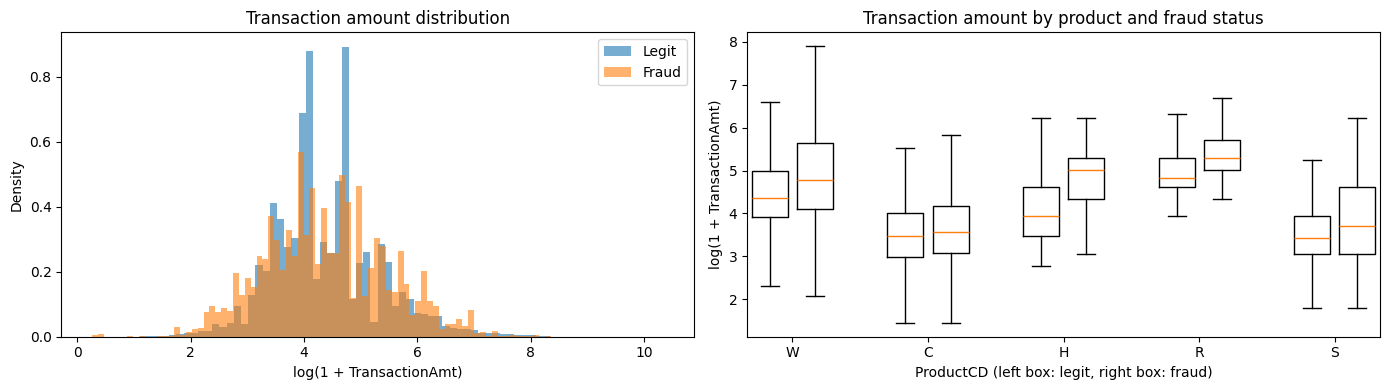

isFraud         0       1
ProductCD                
C           31.25   34.56
H           50.00  150.00
R          125.00  200.00
S           30.00   40.00
W           77.95  117.00


In [49]:
# DO (Branch 3, H1): transaction amount by fraud status, overall and within product
amt = train_df[["TransactionAmt", "isFraud", "ProductCD"]].copy()
amt["log_amt"] = np.log1p(amt["TransactionAmt"])  # amounts are heavily right-skewed

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for label, grp in amt.groupby("isFraud"):
    axes[0].hist(grp["log_amt"], bins=80, alpha=0.6, density=True,
                 label="Fraud" if label == 1 else "Legit")
axes[0].set_xlabel("log(1 + TransactionAmt)")
axes[0].set_ylabel("Density")
axes[0].set_title("Transaction amount distribution")
axes[0].legend()

products = ["W", "C", "H", "R", "S"]
data = [amt.loc[(amt["ProductCD"] == p) & (amt["isFraud"] == f), "log_amt"]
        for p in products for f in (0, 1)]
positions = [i * 3 + j for i in range(len(products)) for j in (0, 1)]
axes[1].boxplot(data, positions=positions, widths=0.8, showfliers=False)
axes[1].set_xticks([i * 3 + 0.5 for i in range(len(products))])
axes[1].set_xticklabels(products)
axes[1].set_xlabel("ProductCD (left box: legit, right box: fraud)")
axes[1].set_ylabel("log(1 + TransactionAmt)")
axes[1].set_title("Transaction amount by product and fraud status")
plt.tight_layout()
plt.show()

print(amt.groupby(["ProductCD", "isFraud"])["TransactionAmt"].median().unstack().round(2))

KeyError: 'hour'

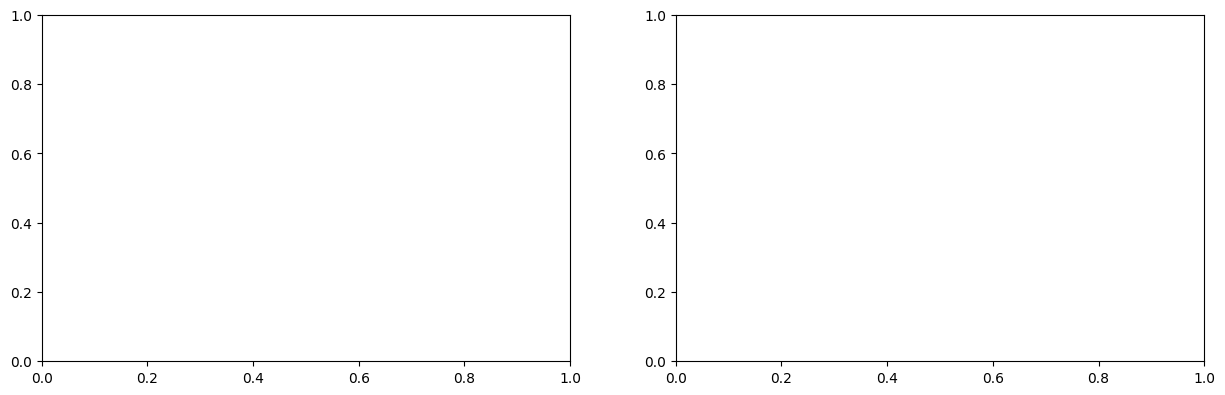

In [50]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

for ax, col, xlabel, title in [
    (axes[0], "hour", "Hour (offset from an unknown reference time)", "Fraud rate and volume by hour"),
    (axes[1], "dow", "Day index mod 7 (weekday unknown)", "Fraud rate and volume by day of week"),
]:
    stats = train_df.groupby(col)["isFraud"].agg(n="size", fraud_rate="mean")

    # Volume bars on the right axis, shaded by volume
    ax2 = ax.twinx()
    norm = mcolors.Normalize(vmin=0, vmax=stats["n"].max())
    bar_colors = plt.cm.Blues(0.25 + 0.6 * norm(stats["n"]))
    ax2.bar(stats.index, stats["n"], color=bar_colors, edgecolor="white", linewidth=0.5)
    ax2.set_ylabel("Transactions", color="tab:blue")
    ax2.tick_params(axis="y", colors="tab:blue")

    # Fraud rate line on the left axis, drawn on top
    ax.plot(stats.index, stats["fraud_rate"], "o-", color="crimson", linewidth=2.2,
            markersize=6, markerfacecolor="white", markeredgewidth=2, zorder=3)
    ax.axhline(train_df["isFraud"].mean(), color="crimson", linestyle="--", linewidth=1,
               alpha=0.6, label=f"Overall rate ({train_df['isFraud'].mean():.2%})")
    ax.set_ylabel("Fraud rate", color="crimson")
    ax.tick_params(axis="y", colors="crimson")
    ax.set_ylim(0, stats["fraud_rate"].max() * 1.15)  # start at 0 so differences aren't exaggerated
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)

    ax.set_xlabel(xlabel)
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(stats.index)
    ax.legend(loc="upper right", fontsize=8, frameon=False)

# Highlight the high-fraud, low-volume window in the hour plot
axes[0].axvspan(4.5, 10.5, color="gold", alpha=0.15, zorder=0)
axes[0].text(7.5, axes[0].get_ylim()[1] * 0.95, "Low volume,\nhigh fraud", ha="center",
             va="top", fontsize=9, color="darkgoldenrod")

plt.tight_layout()
plt.show()

In [51]:
hour_prod = train_df.pivot_table(index="hour", columns="ProductCD", values="isFraud", aggfunc="mean")

fig, ax = plt.subplots(figsize=(10, 4))
for p in ["W", "C", "H", "R", "S"]:
    ax.plot(hour_prod.index, hour_prod[p], "o-", markersize=3, label=p)
ax.set_xlabel("Hour (offset from an unknown reference time)")
ax.set_ylabel("Fraud rate")
ax.set_title("Fraud rate by hour within each product")
ax.legend(title="ProductCD")
plt.show()

KeyError: 'hour'

In [52]:
night = train_df["hour"].between(5, 10)

rows = []
for p in ["W", "C", "H", "R", "S"]:
    m = train_df["ProductCD"] == p
    a, n1 = train_df.loc[m & night, "isFraud"].sum(), (m & night).sum()
    b, n2 = train_df.loc[m & ~night, "isFraud"].sum(), (m & ~night).sum()
    rr = (a / n1) / (b / n2)
    se = np.sqrt(1 / a - 1 / n1 + 1 / b - 1 / n2)
    rows.append({"ProductCD": p, "n_night": n1, "fraud_night": a / n1,
                 "n_other": n2, "fraud_other": b / n2, "RR": rr,
                 "ci_low": np.exp(np.log(rr) - 1.96 * se), "ci_high": np.exp(np.log(rr) + 1.96 * se)})

print(pd.DataFrame(rows).round(4).to_string(index=False))

KeyError: 'hour'

**B3-H2 check:** Confirmed for hour of day; not supported for day of week.

**Hour of day:** fraud rises sharply during hours 5 to 10, which are also the lowest-volume hours of the day (most likely night-time, although the reference time of `TransactionDT` is unknown). Overall, the fraud rate peaks near 10% in this window, compared with about 3% at other hours.

The pattern holds **within every product type**, so it is not explained by product mix:

- **Product `C`:** rises from about 10% to 37% at hours 9 and 10.
- **Product `H`:** peaks near 26% at hour 9, from a baseline of about 4%.
- **Product `W`:** rises from about 2% to 5.4%, small in absolute terms but more than 2.5 times its baseline. Because `W` contains the most fraud cases, this still matters.
- **Product `R`:** rises modestly, to about 10% to 12%.
- **Product `S`:** fluctuates sharply between neighboring hours, reflecting very few night-time transactions rather than a real pattern.

Comparing hours 5 to 10 with all other hours, the relative risk is meaningful in every product (entire 95% CI above 1.5):

| Product | Night: n | Night: fraud | Other hours: n | Other hours: fraud | RR (95% CI) |
|---|---|---|---|---|---|
| W | 14,839 | 3.31% | 331,162 | 2.01% | 1.64 (1.50 to 1.80) |
| C | 4,911 | 20.59% | 51,499 | 10.45% | 1.97 (1.86 to 2.09) |
| H | 1,771 | 10.67% | 27,920 | 4.26% | 2.51 (2.17 to 2.90) |
| R | 1,183 | 7.44% | 31,020 | 3.48% | 2.13 (1.73 to 2.63) |
| S | 384 | 13.02% | 7,743 | 5.85% | 2.23 (1.69 to 2.93) |

Although product `S` fluctuates sharply from hour to hour, pooling hours 5 to 10 gives enough transactions for a reliable estimate. Product `W` has the smallest relative effect but still contributes the most night-time fraud cases after product `C`, because of its size.

The 5 to 10 window was chosen after inspecting the hourly plot, so these relative risks are likely somewhat optimistic. The consistency of the pattern across all five products makes it credible, but its strength should be confirmed on the validation period during modeling.

**Day of week:** fraud rates range only from about 3.2% to 3.8% across the seven days, close to the overall 3.51%. Day of week shows little signal.

**Implication:** hour of day is a strong candidate feature. Because the effect size differs by product, tree-based models can capture the hour-by-product interaction directly. Hour should be encoded to reflect that it wraps around (hour 23 is next to hour 0), for example with sine and cosine transforms or as a categorical feature. Day of week is low priority.


In [53]:
# Branch 3, H2
log("3. Feature signal (H2)",
    "Fraud peaks in hours 5-10 (lowest-volume hours); within every product RR 1.64-2.51, all CIs above 1.5 "
    "(W 1.64, C 1.97, H 2.51, R 2.13, S 2.23); window chosen post hoc so RRs somewhat optimistic; "
    "day of week shows little signal (3.2%-3.8%)",
    "Add hour of day as a feature (cyclical encoding); rely on tree models for hour x product interaction; "
    "confirm hour effect on validation period; day of week low priority")

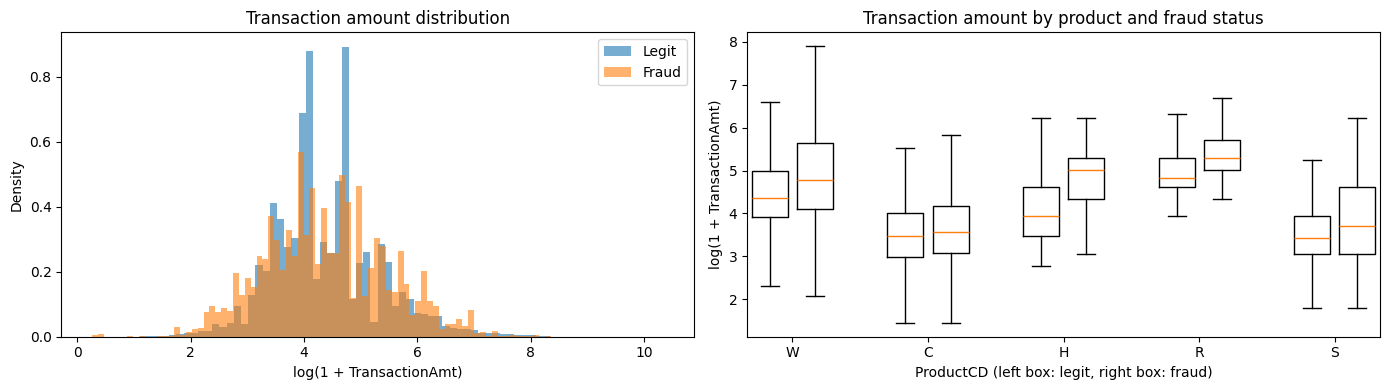

isFraud         0       1
ProductCD                
C           31.25   34.56
H           50.00  150.00
R          125.00  200.00
S           30.00   40.00
W           77.95  117.00


In [54]:
# DO (Branch 3, H1): transaction amount by fraud status, overall and within product
amt = train_df[["TransactionAmt", "isFraud", "ProductCD"]].copy()
amt["log_amt"] = np.log1p(amt["TransactionAmt"])  # amounts are heavily right-skewed

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for label, grp in amt.groupby("isFraud"):
    axes[0].hist(grp["log_amt"], bins=80, alpha=0.6, density=True,
                 label="Fraud" if label == 1 else "Legit")
axes[0].set_xlabel("log(1 + TransactionAmt)")
axes[0].set_ylabel("Density")
axes[0].set_title("Transaction amount distribution")
axes[0].legend()

products = ["W", "C", "H", "R", "S"]
data = [amt.loc[(amt["ProductCD"] == p) & (amt["isFraud"] == f), "log_amt"]
        for p in products for f in (0, 1)]
positions = [i * 3 + j for i in range(len(products)) for j in (0, 1)]
axes[1].boxplot(data, positions=positions, widths=0.8, showfliers=False)
axes[1].set_xticks([i * 3 + 0.5 for i in range(len(products))])
axes[1].set_xticklabels(products)
axes[1].set_xlabel("ProductCD (left box: legit, right box: fraud)")
axes[1].set_ylabel("log(1 + TransactionAmt)")
axes[1].set_title("Transaction amount by product and fraud status")
plt.tight_layout()
plt.show()

print(amt.groupby(["ProductCD", "isFraud"])["TransactionAmt"].median().unstack().round(2))

**B3-H1 check:** Confirmed.

**Overall:** legitimate transaction amounts cluster tightly around a few specific values, visible as tall spikes in the distribution, which likely correspond to common price points. Fraudulent amounts are more spread out, with relatively more transactions at both very low and very high amounts.

**Within products:** the median fraud amount is higher than the median legitimate amount in every product type, so the difference is not explained by product mix:

| Product | Legit median | Fraud median | Fraud / legit |
|---|---|---|---|
| H | $50.00 | $150.00 | 3.0x |
| R | $125.00 | $200.00 | 1.6x |
| W | $77.95 | $117.00 | 1.5x |
| S | $30.00 | $40.00 | 1.3x |
| C | $31.25 | $34.56 | 1.1x |

The shift is largest for product `H`, where the median fraud amount is three times the legitimate one, and smallest for product `C`, where fraud is better distinguished by identity presence and hour of day. Fraud amounts also vary more than legitimate amounts, especially for products `W` and `S`.

The medians for products `H`, `R`, and `S` are round numbers, suggesting these products are sold at fixed price tiers, with fraud concentrated in the higher tiers.

**Implication:** `TransactionAmt` is a useful feature and needs no transformation for tree-based models. Because typical amounts differ strongly by product, an amount-relative-to-product feature (for example, the amount divided by the product's median legitimate amount, computed on training data only) may add signal. The concentration of legitimate transactions at common price points and fixed price tiers suggests a frequency-based feature for amounts may also help.

In [55]:
log("3. Feature signal (H1)",
    "Fraud median amount higher than legit within every product: H $150 vs $50 (3.0x), R $200 vs $125, "
    "W $117 vs $78, S $40 vs $30, C $34.56 vs $31.25 (1.1x); legit amounts cluster at common price points; "
    "H/R/S medians suggest fixed price tiers",
    "Keep TransactionAmt (no transform needed for trees); consider amount relative to product median "
    "and amount-frequency features (computed on train only); test decimal-places feature later")

#### B3-H3: Card attributes

**Plan:** Card network (`card4`) and card type (`card6`) are associated with fraud rate, and the associations hold within product type.

For each category, the fraud rate is compared with the overall rate using relative risk (category fraud rate divided by the rate among all other transactions), with a 95% confidence interval. Categories with very few transactions are flagged, since their rates are unstable.

In [56]:
# DO (B3-H3): fraud rate by card network and card type
def category_rr(data, col, min_n=1000):
    """Fraud rate per category vs all other transactions, with RR and 95% CI."""
    rows = []
    for cat, grp in data.groupby(col, dropna=False):
        rest = data[data[col] != cat] if pd.notna(cat) else data[data[col].notna()]
        a, n1 = grp["isFraud"].sum(), len(grp)
        b, n2 = rest["isFraud"].sum(), len(rest)
        rr = (a / n1) / (b / n2) if a > 0 and b > 0 else np.nan
        se = np.sqrt(1 / a - 1 / n1 + 1 / b - 1 / n2) if a > 0 and b > 0 else np.nan
        rows.append({
            col: "missing" if pd.isna(cat) else cat,
            "n": n1,
            "share": n1 / len(data),
            "fraud_rate": a / n1,
            "RR_vs_rest": rr,
            "ci_low": np.exp(np.log(rr) - 1.96 * se),
            "ci_high": np.exp(np.log(rr) + 1.96 * se),
            "reliable": n1 >= min_n,
        })
    return pd.DataFrame(rows).sort_values("n", ascending=False)

for col in ["card4", "card6"]:
    print(f"\n=== {col} ===")
    print(category_rr(train_df, col).round(4).to_string(index=False))


=== card4 ===
           card4      n  share  fraud_rate  RR_vs_rest  ci_low  ci_high  reliable
            visa 308141 0.6522      0.0347      0.9671  0.9374   0.9978      True
      mastercard 150862 0.3193      0.0349      0.9904  0.9591   1.0228      True
american express   7202 0.0152      0.0286      0.8118  0.7089   0.9295      True
        discover   5394 0.0114      0.0743      2.1435  1.9485   2.3580      True
         missing    833 0.0018      0.0312      0.8882  0.6082   1.2970     False

=== card6 ===
          card6      n  share  fraud_rate  RR_vs_rest  ci_low  ci_high  reliable
          debit 349843 0.7405      0.0240      0.3578  0.3473   0.3686      True
         credit 121716 0.2576      0.0673      2.8057  2.7235   2.8904      True
        missing    828 0.0018      0.0290      0.8247  0.5559   1.2236     False
debit or credit     30 0.0001      0.0000         NaN     NaN      NaN     False
    charge card     15 0.0000      0.0000         NaN     NaN      NaN   

In [57]:
# Within-product check: fraud rate and counts by card attribute and product
for col in ["card4", "card6"]:
    rates = train_df.pivot_table(index=col, columns="ProductCD", values="isFraud", aggfunc="mean")
    counts = train_df.pivot_table(index=col, columns="ProductCD", values="isFraud", aggfunc="size")
    print(f"\n=== {col}: fraud rate by product ===")
    print(rates.round(4))
    print(f"\n=== {col}: transaction counts by product ===")
    print(counts.fillna(0).astype(int))


=== card4: fraud rate by product ===
ProductCD              C       H       R       S       W
card4                                                   
american express  1.0000  0.0560  0.0175  0.0653     NaN
discover             NaN  0.0663  0.0441  0.0924  0.0815
mastercard        0.1088  0.0510  0.0493  0.0666  0.0177
visa              0.1163  0.0436  0.0367  0.0567  0.0213

=== card4: transaction counts by product ===
ProductCD             C      H      R     S       W
card4                                              
american express      2   1374   5305   521       0
discover              0    558    952   498    3386
mastercard        22573   7137   6409  2026  112717
visa              33758  20614  19536  5082  229151

=== card6: fraud rate by product ===
ProductCD             C       H       R       S       W
card6                                                  
charge card      0.0000     NaN  0.0000     NaN     NaN
credit           0.1651  0.0495  0.0382  0.0600  0.0444


**B3-H3 check:** Partly confirmed. Card type carries real signal within the largest products; card network mostly does not.

**Card type (`card6`):** overall, credit transactions have a fraud rate of 6.73% versus 2.40% for debit (2.8x). The effect holds within the two products that contain most fraud:

| Product | Credit fraud | Debit fraud | Credit / debit |
|---|---|---|---|
| W | 4.44% | 1.61% | 2.76x |
| C | 16.51% | 7.76% | 2.13x |
| R | 3.82% | 3.18% | 1.20x |
| H | 4.95% | 4.27% | 1.16x |
| S | 6.00% | 6.39% | 0.94x |

Products `W` and `C` together hold about 82% of fraud cases, so the credit effect applies where it matters most. For `H`, `R`, and `S`, credit and debit fraud rates are similar. The categories "charge card" (15 transactions) and "debit or credit" (30) are too small to interpret.

**Card network (`card4`):**

- **Visa vs Mastercard:** fraud rates are nearly identical overall (3.47% vs 3.49%) and differ by only about 1 percentage point in either direction within products. Card network does not distinguish Mastercard from Visa in terms of fraud risk.
- **Discover:** the overall relative risk of 2.14 comes mainly from product `W`, where Discover fraud is 8.15%, roughly 4 times Visa (2.13%) and Mastercard (1.77%). In other products, the difference is small.
- **American Express:** appears mostly in product `R`, where its fraud rate (1.75%) is about half that of Visa (3.67%). Its lower overall rate also reflects its absence from product `W` and near-absence from product `C`.

Card networks are unevenly distributed across products: product `C` has no Discover transactions and only 2 American Express transactions, and product `W` has no American Express transactions. Overall network comparisons therefore partly reflect product mix.

**Implication:** keep `card6` as a feature; the credit/debit difference is strong within products `W` and `C`. Keep `card4`, mainly for the Discover signal in product `W`. Tree-based models can capture these product-specific interactions directly.

In [58]:
log("3. Feature signal (H3)",
    "Credit vs debit fraud 6.73% vs 2.40% overall; holds within W (2.76x) and C (2.13x), which hold ~82% of fraud; "
    "near 1x in H/R/S. Visa vs Mastercard no consistent difference; Discover ~4x Visa/Mastercard within W only; "
    "Amex lower mainly within R; card networks unevenly spread across products",
    "Keep card6 (strong within W and C) and card4 (mainly Discover in W); rely on tree models for "
    "card x product interactions; ignore rare card6 categories")

#### B3-H4: Email domains

**Plan:**

- **B3-H4a:** Some purchaser email domains have substantially higher fraud rates than others.
- **B3-H4b:** Whether the purchaser and recipient domains match is associated with fraud rate.

Domains are analyzed both as-is and grouped by provider (the part before the first dot, so `yahoo.com` and `yahoo.fr` both become `yahoo`). Because many domains are rare, only categories with at least 1,000 transactions are treated as reliable. As with earlier hypotheses, results are checked within product type.

In [59]:
# DO (B3-H4a): fraud rate by purchaser email domain and provider
train_df["P_provider"] = train_df["P_emaildomain"].str.split(".").str[0]
train_df["R_provider"] = train_df["R_emaildomain"].str.split(".").str[0]

print(f"Distinct purchaser domains: {train_df['P_emaildomain'].nunique()}, "
      f"providers: {train_df['P_provider'].nunique()}")

p_domain = category_rr(train_df, "P_emaildomain")
print("\n=== Purchaser domains: 15 most common ===")
print(p_domain.head(15).round(4).to_string(index=False))

print("\n=== Purchaser domains: highest fraud rate among reliable (n >= 1000) ===")
print(p_domain[p_domain["reliable"]].sort_values("RR_vs_rest", ascending=False)
      .head(10).round(4).to_string(index=False))

print("\n=== Purchaser providers: 15 most common ===")
print(category_rr(train_df, "P_provider").head(15).round(4).to_string(index=False))

Distinct purchaser domains: 59, providers: 44

=== Purchaser domains: 15 most common ===
P_emaildomain      n  share  fraud_rate  RR_vs_rest  ci_low  ci_high  reliable
    gmail.com 182692 0.3867      0.0440      1.4894  1.4456   1.5346      True
    yahoo.com  80854 0.1711      0.0229      0.6090  0.5806   0.6387      True
      missing  73586 0.1558      0.0298      0.8260  0.7902   0.8633      True
  hotmail.com  37158 0.0787      0.0520      1.5439  1.4742   1.6170      True
anonymous.com  29961 0.0634      0.0233      0.6473  0.6006   0.6977      True
      aol.com  22618 0.0479      0.0219      0.6113  0.5596   0.6678      True
  comcast.net   6496 0.0138      0.0300      0.8526  0.7420   0.9798      True
   icloud.com   5031 0.0106      0.0318      0.9042  0.7758   1.0539      True
  outlook.com   4080 0.0086      0.0917      2.6461  2.3996   2.9178      True
      msn.com   3340 0.0071      0.0177      0.5010  0.3889   0.6454      True
      att.net   3133 0.0066      0.0064   

In [60]:
# DO (B3-H4b): does the recipient domain match the purchaser domain?
train_df["email_match"] = np.select(
    [train_df["R_emaildomain"].isna(),
     train_df["P_emaildomain"].isna(),
     train_df["P_emaildomain"] == train_df["R_emaildomain"]],
    ["no recipient", "no purchaser", "same domain"],
    default="different domain",
)

print("=== Email match overall ===")
print(category_rr(train_df, "email_match").round(4).to_string(index=False))

# Within-product check
rates = train_df.pivot_table(index="email_match", columns="ProductCD", values="isFraud", aggfunc="mean")
counts = train_df.pivot_table(index="email_match", columns="ProductCD", values="isFraud", aggfunc="size")
print("\n=== Email match: fraud rate by product ===")
print(rates.round(4))
print("\n=== Email match: counts by product ===")
print(counts.fillna(0).astype(int))

=== Email match overall ===
     email_match      n  share  fraud_rate  RR_vs_rest  ci_low  ci_high  reliable
    no recipient 358812 0.7595      0.0211      0.2665  0.2587   0.2746      True
     same domain  85848 0.1817      0.0929      4.1622  4.0411   4.2870      True
different domain  20121 0.0426      0.0282      0.7950  0.7320   0.8634      True
    no purchaser   7651 0.0162      0.0618      1.7818  1.6307   1.9469      True

=== Email match: fraud rate by product ===
ProductCD              C       H       R       S       W
email_match                                             
different domain     NaN  0.0318  0.0259     NaN     NaN
no purchaser         NaN  0.0000  0.0667  0.0618     NaN
no recipient      0.1387  0.0101  0.0000  0.0630  0.0207
same domain       0.1123  0.0880  0.0427     NaN     NaN

=== Email match: counts by product ===
ProductCD             C      H      R     S       W
email_match                                        
different domain      0   7862  

In [61]:
# Within-product check for the top purchaser providers
top_providers = train_df["P_provider"].value_counts().head(8).index
sub = train_df[train_df["P_provider"].isin(top_providers)]
print("=== Top providers: fraud rate by product ===")
print(sub.pivot_table(index="P_provider", columns="ProductCD", values="isFraud", aggfunc="mean").round(4))
print("\n=== Top providers: counts by product ===")
print(sub.pivot_table(index="P_provider", columns="ProductCD", values="isFraud", aggfunc="size")
      .fillna(0).astype(int))

=== Top providers: fraud rate by product ===
ProductCD        C       H       R       W
P_provider                                
anonymous   0.0651  0.0398  0.0107  0.0130
aol         0.0984  0.0234  0.0128  0.0225
comcast     0.0000  0.0359  0.0084  0.0340
gmail       0.1656  0.0581  0.0657  0.0207
hotmail     0.0759  0.0650  0.0160  0.0167
icloud      0.1302  0.0405  0.0913  0.0193
outlook     0.1573  0.1379  0.1689  0.0248
yahoo       0.0462  0.0300  0.0402  0.0203

=== Top providers: counts by product ===
ProductCD       C      H      R       W
P_provider                             
anonymous    4763   2916   8010   14272
aol            61   1669   2113   18775
comcast         6    892   1075    4523
gmail       22353  13590  11319  135841
hotmail     20477   2232   1622   13405
icloud        361    296    230    4144
outlook      1990    145    225    2097
yahoo        2509   4974   4431   70551


**B3-H4 check:** Partly confirmed. Email domains carry signal, but mainly within products `C`, `H`, and `R`; much of the overall pattern reflects product mix.

**Email match (B3-H4b):** email structure is largely determined by product type. Product `W` never has a recipient email, product `C` almost always has matching domains, and product `S` almost never has a purchaser email. Only products `H` and `R` have a mix of matching and non-matching domains. As a result, the overall comparison (9.29% fraud for matching domains vs 2.11% with no recipient) mainly reflects product type. Within products:

| Product | Same domain | Different domain | No recipient |
|---|---|---|---|
| C | 11.23% (54,298) | n/a | 13.87% (2,112) |
| H | 8.80% (11,634) | 3.18% (7,862) | 1.01% (10,194) |
| R | 4.27% (19,916) | 2.59% (12,259) | n/a* |

\*Only 13 transactions.

Matching domains are associated with higher fraud only in products `H` (2.8x vs different) and `R` (1.6x). In product `C`, the direction reverses.

**Purchaser provider (B3-H4a):** overall, Outlook (9.49% fraud), Hotmail (5.16%), and Gmail (4.39%) appear higher-risk, while Yahoo, AOL, and MSN appear lower-risk. Within products, the picture is more specific:

- **Product `W`:** provider makes little difference. Most providers fall between 1.7% and 2.5%, close to the product baseline of 2.07%.
- **Products `C`, `H`, and `R`:** Gmail and Outlook are consistently above their product's average (for example, Gmail is 16.6% within product `C`, versus 11.3% for the product overall), while Yahoo, AOL, and `anonymous` are consistently below.
- **Hotmail:** its higher overall rate reflects product mix. Over half of Hotmail transactions are product `C`, but within both product `C` (7.59%) and product `W` (1.67%), Hotmail is below average.
- **Internet-provider domains** (`att.net`, `sbcglobal.net`, `verizon.net`) have very low overall fraud rates (0.46% to 0.67%). <Within-product result to confirm.>

Grouping domains by provider (59 domains into 44 providers) changes the rates very little and will absorb new domain variants in later data, so the provider version is preferred.

**Implication:** keep purchaser provider as a feature; its signal is concentrated in products `C`, `H`, and `R`, which tree-based models can capture through interactions with `ProductCD`. The email-match feature mostly duplicates product type and adds information only for products `H` and `R`, so it is lower priority.

In [62]:
log("3. Feature signal (H4)",
    "Email structure largely determined by product (W never has recipient; C almost always same domain). "
    "Same-domain effect only in H (2.8x vs different) and R (1.6x); reverses in C. Provider barely matters "
    "within W; within C/H/R, Gmail and Outlook high, Yahoo/AOL/anonymous low; Hotmail's overall elevation "
    "is product mix",
    "Keep P_provider (grouped domain) as feature, relying on tree models for provider x product interaction; "
    "email_match low priority (mostly duplicates ProductCD); confirm ISP-domain effect within product")

#### B3-H5: Device information

**Plan:** Among transactions with identity data, device type (`DeviceType`) and device family (grouped from `DeviceInfo`) are associated with fraud rate, and the associations hold within product type.

Because device data comes from the identity table, this analysis is limited to transactions with identity data (products `C`, `H`, `R`, and `S`). Product `W` has no device information. `DeviceInfo` contains many specific model and OS strings, so values are grouped into device families (for example, all Samsung model codes become `samsung`) before analysis.

In [63]:
# DO (B3-H5): device information among transactions with identity data
ident = train_df[train_df["has_identity"] == 1].copy()

def device_family(s):
    if pd.isna(s):
        return "missing"
    s = s.lower()
    rules = [
        ("windows", "windows"), ("ios", "ios"), ("macos", "macos"),
        ("trident", "windows"),                    # Internet Explorer on Windows
        ("sm-", "samsung"), ("samsung", "samsung"), ("gt-", "samsung"),
        ("moto", "motorola"), ("lg", "lg"), ("huawei", "huawei"), ("ale-", "huawei"),
        ("pixel", "google"), ("nexus", "google"), ("redmi", "xiaomi"), ("mi ", "xiaomi"),
        ("htc", "htc"), ("lenovo", "lenovo"), ("zte", "zte"), ("blade", "zte"),
        ("linux", "linux"), ("rv:", "firefox"),
    ]
    for key, fam in rules:
        if key in s:
            return fam
    return "other"

ident["device_family"] = ident["DeviceInfo"].apply(device_family)
train_df.loc[ident.index, "device_family"] = ident["device_family"]

print(f"Transactions with identity data: {len(ident):,}")
print(f"Distinct DeviceInfo values: {ident['DeviceInfo'].nunique():,} -> "
      f"device families: {ident['device_family'].nunique()}")

for col in ["DeviceType", "device_family"]:
    print(f"\n=== {col} (identity transactions only) ===")
    print(category_rr(ident, col).round(4).to_string(index=False))

Transactions with identity data: 120,464
Distinct DeviceInfo values: 1,639 -> device families: 16

=== DeviceType (identity transactions only) ===
DeviceType     n  share  fraud_rate  RR_vs_rest  ci_low  ci_high  reliable
   desktop 71545 0.5939      0.0624      0.6588  0.6333   0.6853      True
    mobile 46093 0.3826      0.0990      1.6245  1.5617   1.6898      True
   missing  2826 0.0235      0.0244      0.3181  0.2517   0.4019      True

=== device_family (identity transactions only) ===
device_family     n  share  fraud_rate  RR_vs_rest  ci_low  ci_high  reliable
      windows 46175 0.3833      0.0551      0.6237  0.5967   0.6520      True
      missing 20928 0.1737      0.1047      1.5085  1.4411   1.5790      True
          ios 17083 0.1418      0.0613      0.7877  0.7402   0.8384      True
        macos 10843 0.0900      0.0185      0.2284  0.1989   0.2623      True
      samsung  9915 0.0823      0.1156      1.6066  1.5155   1.7033      True
        other  3994 0.0332      0

In [64]:
# Within-product check
for col in ["DeviceType", "device_family"]:
    rates = ident.pivot_table(index=col, columns="ProductCD", values="isFraud", aggfunc="mean")
    counts = ident.pivot_table(index=col, columns="ProductCD", values="isFraud", aggfunc="size")
    print(f"\n=== {col}: fraud rate by product ===")
    print(rates.round(4))
    print(f"\n=== {col}: counts by product ===")
    print(counts.fillna(0).astype(int))


=== DeviceType: fraud rate by product ===
ProductCD        C       H       R       S
DeviceType                                
desktop     0.1131  0.0419  0.0213  0.0453
mobile      0.1297  0.0552  0.0726  0.1325

=== DeviceType: counts by product ===
ProductCD       C      H      R     S
DeviceType                           
desktop     26532  17173  21565  6275
mobile      23233  11701   9551  1608

=== device_family: fraud rate by product ===
ProductCD           C       H       R       S
device_family                                
firefox        0.1355  0.0702  0.0472  0.0223
google         0.1964  0.0439  0.0000  0.0000
htc            0.1000  0.0000  0.0000  0.3333
huawei         0.0980  0.3333     NaN     NaN
ios               NaN  0.0500  0.0718  0.0900
lenovo         0.1155  0.0000  0.0000  0.0000
lg             0.1207  0.0437  0.1778  0.0227
linux          0.0000  0.0000  0.0000  0.0000
macos             NaN  0.0132  0.0196  0.0437
missing        0.1153  0.0324  0.0460  0.0

In [65]:
print(ident.loc[ident["device_family"] == "other", "DeviceInfo"].value_counts().head(20))

DeviceInfo
hi6210sft Build/MRA58K            190
F3213 Build/36.1.A.1.86            85
XT1635-02 Build/NPN26.118-22-2     70
F3113 Build/33.3.A.1.97            66
KFFOWI Build/LVY48F                64
Hisense L675 Build/MRA58K          56
F5121 Build/34.3.A.0.252           49
F3313 Build/37.0.A.2.108           48
es-us                              46
F5121 Build/34.3.A.0.238           45
MDDRJS                             44
XT1032 Build/LPBS23.13-56-2        42
5010G Build/MRA58K                 40
Ilium LT510 Build/MRA58K           38
5080A Build/MRA58K                 38
Hisense F23 Build/NRD90M           37
XT1585 Build/NCK25.118-10.5        35
M4 SS4453 Build/MMB29M             35
G3313 Build/43.0.A.5.79            35
8050G Build/LMY47I                 35
Name: count, dtype: int64


In [66]:
def device_family(s):
    if pd.isna(s):
        return "missing"
    s = s.lower()
    rules = [
        ("windows", "windows"), ("ios", "ios"), ("macos", "macos"),
        ("trident", "windows"),
        ("sm-", "samsung"), ("samsung", "samsung"), ("gt-", "samsung"),
        ("moto", "motorola"), ("xt1", "motorola"),
        ("lg", "lg"), ("huawei", "huawei"), ("ale-", "huawei"), ("hi6210sft", "huawei"),
        ("pixel", "google"), ("nexus", "google"), ("redmi", "xiaomi"), ("mi ", "xiaomi"),
        ("htc", "htc"), ("lenovo", "lenovo"), ("zte", "zte"), ("blade", "zte"),
        ("linux", "linux"), ("rv:", "firefox"),
        ("build/", "android_other"),   # any remaining Android build string
    ]
    for key, fam in rules:
        if key in s:
            return fam
    return "other"

ident["device_family"] = ident["DeviceInfo"].apply(device_family)
train_df.loc[ident.index, "device_family"] = ident["device_family"]

print(category_rr(ident, "device_family").round(4).to_string(index=False))
print(ident.pivot_table(index="device_family", columns="ProductCD", values="isFraud", aggfunc="mean").round(4))

device_family     n  share  fraud_rate  RR_vs_rest  ci_low  ci_high  reliable
      windows 46175 0.3833      0.0551      0.6237  0.5967   0.6520      True
      missing 20928 0.1737      0.1047      1.5085  1.4411   1.5790      True
          ios 17083 0.1418      0.0613      0.7877  0.7402   0.8384      True
        macos 10843 0.0900      0.0185      0.2284  0.1989   0.2623      True
      samsung  9915 0.0823      0.1156      1.6066  1.5155   1.7033      True
      firefox  3810 0.0316      0.0730      0.9649  0.8602   1.0825      True
     motorola  2717 0.0226      0.1542      2.0920  1.9112   2.2898      True
android_other  2448 0.0203      0.1850      2.5259  2.3187   2.7515      True
           lg  2111 0.0175      0.1127      1.5059  1.3338   1.7001      True
       huawei  2033 0.0169      0.1781      2.4136  2.1937   2.6557      True
        other   884 0.0073      0.0656      0.8678  0.6761   1.1138     False
          zte   409 0.0034      0.1687      2.2429  1.8071   2.7

**B3-H5 check:** Partly confirmed. Device type carries a genuine signal; most device-family differences reflect product mix, except for unrecognized devices.

Device information is available only for transactions with identity data (120,464 transactions in products `C`, `H`, `R`, and `S`). Relative risks below compare each category with the other identity transactions.

**Device type:** overall, mobile transactions have a fraud rate of 9.90% versus 6.24% for desktop. Mobile is riskier within every product:

| Product | Mobile fraud | Desktop fraud | Mobile / desktop |
|---|---|---|---|
| R | 7.26% | 2.13% | 3.41x |
| S | 13.25% | 4.53% | 2.92x |
| H | 5.52% | 4.19% | 1.32x |
| C | 12.97% | 11.31% | 1.15x |

The effect is strongest in products `R` and `S` and smallest in product `C`. Transactions with missing `DeviceType` (2,826) have a low fraud rate (2.44%).

**Device family:** the 1,639 distinct `DeviceInfo` values were grouped into device families. Android build strings not matching a named brand (such as Sony, Alcatel, Hisense, and Amazon Fire devices) were grouped as `android_other`.

- **Apple devices** appear lower-risk overall (macOS 1.85%, iOS 6.13%), but neither appears in product `C`, the highest-fraud product. Within other products the difference is inconsistent: macOS is clearly lower than Windows in product `H` (1.32% vs 5.23%) but similar in products `R` and `S`.
- **Android devices are riskier than Windows within product `C`**, and less common brands are riskiest:

| Family | Product `C` fraud |
|---|---|
| Huawei | 17.76% |
| Motorola | 16.33% |
| Android (other brands) | 16.29% |
| Samsung | 14.39% |
| LG | 12.07% |
| Windows | 9.45% |

- **Less common Android devices (`android_other`)** have the highest fraud rate of any sizable family overall: 18.50% across 2,448 transactions (RR 2.53, 95% CI 2.32 to 2.75). Their rates in products `H`, `R`, and `S` are also high but based on small groups, so the product `C` result is the most reliable.
- **Missing `DeviceInfo`** appears higher-risk overall (RR 1.51), but 81% of these transactions are product `C`, and within `C` their fraud rate (11.53%) matches the product average. The overall effect reflects product mix.
- **Unrecognized strings (`other`)**, 884 transactions, have a fraud rate near the average (6.56%) and show no clear signal.
- Families with fewer than 1,000 transactions (ZTE, HTC, Google, Lenovo, Xiaomi, Linux) are too small to interpret individually.

In [67]:
log("3. Feature signal (H5)",
    "Identity transactions only (no product W). Mobile vs desktop fraud 9.90% vs 6.24%; mobile riskier within "
    "every product (R 3.41x, S 2.92x, H 1.32x, C 1.15x). Apple devices absent from product C, so their low "
    "overall rates partly product mix. Within C, all Android families above Windows (9.45%): Huawei 17.8%, "
    "Motorola 16.3%, less common Android 16.3%, Samsung 14.4%. Less common Android devices 18.5% overall "
    "(RR 2.53, CI 2.32-2.75); missing DeviceInfo is mostly product C",
    "Keep DeviceType and grouped device family (not raw DeviceInfo), with less common Android brands grouped; "
    "device features inform identity transactions only")

### Branch 4: Entity Structure

The labeling logic defines fraud at the level of cards and accounts: once a chargeback is reported, later transactions linked to the same account, email address, or billing address are also labeled fraud. Fraud should therefore cluster by entity. The dataset has no customer ID, so entities are approximated from existing columns.

**Plan**

- **B4-H1:** `D1` counts days since the card was first used. If so, `day − D1` (the card's start day) is nearly constant within each `card1` + `addr1` group, and combining the three columns gives a finer entity key (`uid`).
- **B4-H2:** Fraud clusters by entity: transactions sharing a `uid` are much more likely to be all fraud or all legitimate than if labels were assigned at random.
- **B4-H3:** Many entities appear in both the training and validation periods, so entity-level information learned in training can apply to later transactions, but must be handled carefully to avoid leakage.

In [68]:
# DO (B4-H1): build entity keys and test whether day - D1 is stable within card1 + addr1
train_df["D1n"] = train_df["day"] - train_df["D1"]  # card start day, if D1 = days since first use

train_df["card_addr"] = train_df["card1"].astype(str) + "_" + train_df["addr1"].astype(str)
train_df["uid"] = train_df["card_addr"] + "_" + train_df["D1n"].astype(str)

for key in ["card1", "card_addr", "uid"]:
    sizes = train_df.groupby(key).size()
    print(f"{key:>10}: {sizes.size:>7,} entities | median size {sizes.median():>5.0f} | "
          f"singletons {(sizes == 1).mean():.1%} | largest {sizes.max():,}")

# Stability check: within each card_addr group, how many distinct D1n values?
multi = train_df.groupby("card_addr").filter(lambda g: len(g) >= 5)
d1n_per_group = multi.groupby("card_addr")["D1n"].nunique()
print(f"\nGroups with 5+ transactions: {d1n_per_group.size:,}")
print(f"Share with a single D1n value: {(d1n_per_group == 1).mean():.1%}")
print(d1n_per_group.describe().round(1))

# Compare with a shuffled baseline: if D1n carried no card-level structure,
# groups would have many more distinct values
shuffled = multi["D1n"].sample(frac=1, random_state=42).values
shuf_nunique = pd.Series(shuffled, index=multi.index).groupby(multi["card_addr"]).nunique()
print(f"\nMedian distinct D1n per group: actual {d1n_per_group.median():.0f}, "
      f"shuffled {shuf_nunique.median():.0f}")

     card1:  12,730 entities | median size     4 | singletons 26.6% | largest 12,205
 card_addr:  36,593 entities | median size     2 | singletons 40.4% | largest 8,088
       uid: 182,535 entities | median size     1 | singletons 58.2% | largest 361

Groups with 5+ transactions: 11,517
Share with a single D1n value: 10.1%
count    11517.0
mean        12.9
std         26.0
min          1.0
25%          3.0
50%          5.0
75%         11.0
max        451.0
Name: D1n, dtype: float64

Median distinct D1n per group: actual 5, shuffled 11


In [69]:
# DO (B4-H2): does fraud cluster within entities?
def entity_purity(data, key, min_size=2, seed=None):
    labels = data["isFraud"]
    if seed is not None:
        labels = labels.sample(frac=1, random_state=seed).set_axis(data.index)
    g = labels.groupby(data[key])
    sizes, frauds = g.size(), g.sum()
    keep = sizes >= min_size
    sizes, frauds = sizes[keep], frauds[keep]
    return pd.Series({
        "entities": len(sizes),
        "all_legit": (frauds == 0).mean(),
        "all_fraud": (frauds == sizes).mean(),
        "mixed": ((frauds > 0) & (frauds < sizes)).mean(),
        "fraud_in_mostly_fraud_entities": frauds[frauds / sizes >= 0.5].sum() / frauds.sum(),
    })

rows = {}
for key in ["card1", "card_addr", "uid"]:
    rows[f"{key} (actual)"] = entity_purity(train_df, key)
    rows[f"{key} (shuffled)"] = entity_purity(train_df, key, seed=42)
print(pd.DataFrame(rows).T.round(3))

                      entities  all_legit  all_fraud  mixed  \
card1 (actual)          9350.0      0.850      0.006  0.144   
card1 (shuffled)        9350.0      0.664      0.000  0.336   
card_addr (actual)     21793.0      0.885      0.010  0.105   
card_addr (shuffled)   21793.0      0.731      0.000  0.269   
uid (actual)           76374.0      0.946      0.021  0.033   
uid (shuffled)         76374.0      0.855      0.001  0.144   

                      fraud_in_mostly_fraud_entities  
card1 (actual)                                 0.053  
card1 (shuffled)                               0.008  
card_addr (actual)                             0.164  
card_addr (shuffled)                           0.027  
uid (actual)                                   0.772  
uid (shuffled)                                 0.187  


In [70]:
# DO (B4-H3): entity overlap between training and validation periods
# Uses validation features only (no labels), like the column-name checks at the start
val_df["D1n"] = (val_df["TransactionDT"] // 86400) - val_df["D1"]
val_df["uid"] = (val_df["card1"].astype(str) + "_" + val_df["addr1"].astype(str)
                 + "_" + val_df["D1n"].astype(str))

train_uids = set(train_df["uid"])
seen = val_df["uid"].isin(train_uids)
print(f"Validation transactions whose uid appears in training: {seen.mean():.1%}")
print(f"Distinct validation uids seen in training: {val_df['uid'].drop_duplicates().isin(train_uids).mean():.1%}")

Validation transactions whose uid appears in training: 43.5%
Distinct validation uids seen in training: 38.1%


In [71]:
purity = pd.DataFrame(rows).T

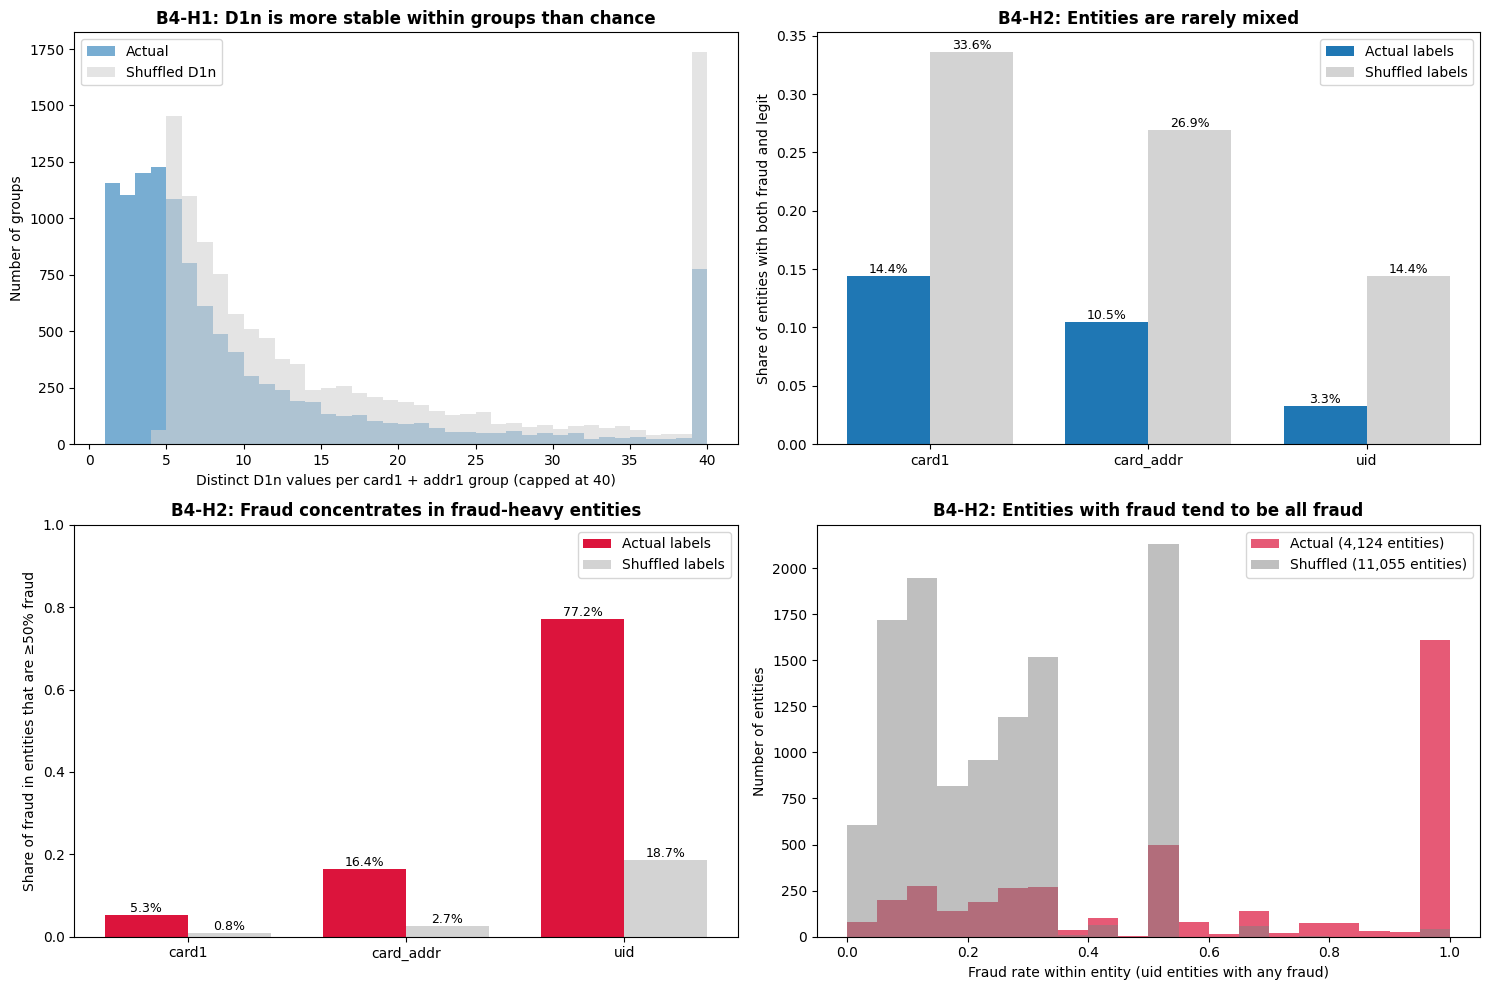

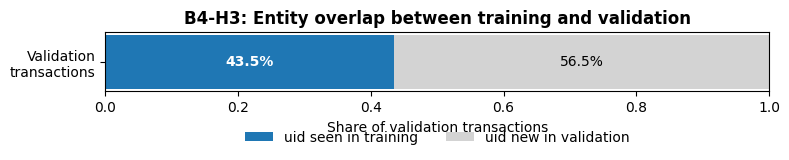

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
keys = ["card1", "card_addr", "uid"]
x = np.arange(len(keys))
w = 0.38

# (1) B4-H1: distinct D1n values per card_addr group, actual vs shuffled
ax = axes[0, 0]
bins = np.arange(1, 41)
ax.hist(d1n_per_group.clip(upper=40), bins=bins, alpha=0.6, label="Actual", color="tab:blue")
ax.hist(shuf_nunique.clip(upper=40), bins=bins, alpha=0.6, label="Shuffled D1n", color="lightgray")
ax.set_xlabel("Distinct D1n values per card1 + addr1 group (capped at 40)")
ax.set_ylabel("Number of groups")
ax.set_title("B4-H1: D1n is more stable within groups than chance", fontweight="bold")
ax.legend()

# (2) B4-H2: share of entities with mixed labels, actual vs shuffled
ax = axes[0, 1]
actual = [purity.loc[f"{k} (actual)", "mixed"] for k in keys]
shuf = [purity.loc[f"{k} (shuffled)", "mixed"] for k in keys]
ax.bar(x - w / 2, actual, w, label="Actual labels", color="tab:blue")
ax.bar(x + w / 2, shuf, w, label="Shuffled labels", color="lightgray")
for i, (a, s) in enumerate(zip(actual, shuf)):
    ax.text(i - w / 2, a, f"{a:.1%}", ha="center", va="bottom", fontsize=9)
    ax.text(i + w / 2, s, f"{s:.1%}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(keys)
ax.set_ylabel("Share of entities with both fraud and legit")
ax.set_title("B4-H2: Entities are rarely mixed", fontweight="bold")
ax.legend()

# (3) B4-H2: share of fraud sitting in mostly-fraud entities
ax = axes[1, 0]
actual = [purity.loc[f"{k} (actual)", "fraud_in_mostly_fraud_entities"] for k in keys]
shuf = [purity.loc[f"{k} (shuffled)", "fraud_in_mostly_fraud_entities"] for k in keys]
ax.bar(x - w / 2, actual, w, label="Actual labels", color="crimson")
ax.bar(x + w / 2, shuf, w, label="Shuffled labels", color="lightgray")
for i, (a, s) in enumerate(zip(actual, shuf)):
    ax.text(i - w / 2, a, f"{a:.1%}", ha="center", va="bottom", fontsize=9)
    ax.text(i + w / 2, s, f"{s:.1%}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(keys)
ax.set_ylim(0, 1)
ax.set_ylabel("Share of fraud in entities that are ≥50% fraud")
ax.set_title("B4-H2: Fraud concentrates in fraud-heavy entities", fontweight="bold")
ax.legend()

# (4) B4-H2: fraud rate per uid entity (2+ transactions), actual vs shuffled
ax = axes[1, 1]
g = train_df.groupby("uid")["isFraud"].agg(["size", "mean"])
g = g[g["size"] >= 2]
shuf_labels = train_df["isFraud"].sample(frac=1, random_state=42).set_axis(train_df.index)
g_shuf = shuf_labels.groupby(train_df["uid"]).agg(["size", "mean"])
g_shuf = g_shuf[g_shuf["size"] >= 2]
fraud_ent = g[g["mean"] > 0]["mean"]
fraud_ent_shuf = g_shuf[g_shuf["mean"] > 0]["mean"]
bins = np.linspace(0, 1, 21)
ax.hist(fraud_ent, bins=bins, alpha=0.7, label=f"Actual ({len(fraud_ent):,} entities)", color="crimson")
ax.hist(fraud_ent_shuf, bins=bins, alpha=0.5, label=f"Shuffled ({len(fraud_ent_shuf):,} entities)", color="gray")
ax.set_xlabel("Fraud rate within entity (uid entities with any fraud)")
ax.set_ylabel("Number of entities")
ax.set_title("B4-H2: Entities with fraud tend to be all fraud", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

# B4-H3: validation overlap
fig, ax = plt.subplots(figsize=(8, 2.2))
ax.barh(["Validation\ntransactions"], [seen.mean()], color="tab:blue", label="uid seen in training")
ax.barh(["Validation\ntransactions"], [1 - seen.mean()], left=[seen.mean()], color="lightgray",
        label="uid new in validation")
ax.text(seen.mean() / 2, 0, f"{seen.mean():.1%}", ha="center", va="center", color="white", fontweight="bold")
ax.text(seen.mean() + (1 - seen.mean()) / 2, 0, f"{1 - seen.mean():.1%}", ha="center", va="center")
ax.set_xlim(0, 1)
ax.set_xlabel("Share of validation transactions")
ax.set_title("B4-H3: Entity overlap between training and validation", fontweight="bold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.45), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

**B4-H1 check:** Partly supported. Within `card1` + `addr1` groups with at least 5 transactions, the median number of distinct `D1n` values (`day − D1`) is 5, compared with 11 when `D1n` is shuffled across transactions. Many groups have only 1 to 4 distinct values, which shuffling never produces. `D1n` therefore carries real card-level structure, consistent with `D1` counting days since the card was first used. However, only 10% of groups have a single value, so `D1n` is not a clean card start date for every transaction. Groups can also contain several genuine cards, since `card1` is shared across many cards.

Combining the three columns gives progressively finer entity keys:

| Key | Entities | Median size | Singletons | Largest |
|---|---|---|---|---|
| `card1` | 12,730 | 4 | 26.6% | 12,205 |
| `card1` + `addr1` | 34,399 | 2 | 40.5% | 4,721 |
| `uid` (+ `D1n`) | 167,111 | 1 | 58.7% | 361 |

**B4-H2 check:** Strongly confirmed. Among entities with at least two transactions, fraud labels cluster far more than chance would produce. Comparing actual labels with randomly shuffled labels (same entity sizes):

| Key | Mixed entities: actual | Mixed: shuffled | Fraud in mostly-fraud entities: actual | Shuffled |
|---|---|---|---|---|
| `card1` | 14.4% | 33.6% | 5.3% | 0.8% |
| `card1` + `addr1` | 9.9% | 26.9% | 22.6% | 2.8% |
| `uid` | 1.5% | 14.0% | 89.4% | 19.5% |

With `uid`, only 1.5% of entities contain both fraud and legitimate transactions, and **89.4% of fraud** sits in entities that are at least half fraud. Fraud is concentrated in 2,234 entities, compared with 9,699 if labels were random, and about 1,230 of these are entirely fraud. This matches the labeling logic, in which transactions linked to a flagged account are also labeled fraud. The finer the entity key, the stronger the clustering.

**B4-H3 check:** Confirmed. **52.0%** of validation transactions belong to a `uid` already seen in training (39.3% of distinct validation `uid`s). About half of later transactions therefore come from known entities, and half from new ones.

**Implications:**

1. **Entity-level features are likely the strongest signal in the data.** Aggregates computed per `uid`, such as transaction counts, typical amounts, and how much a transaction deviates from its entity's usual behavior, can describe each account's pattern without using fraud labels.
2. **Label-based entity features are a leakage risk.** Features built from an entity's fraud labels (for example, the share of an entity's past transactions that were fraud) would let the model memorize known fraud accounts. In practice, chargebacks are reported with a delay, so recent labels would not be available at prediction time. Any such feature must use only labels that would genuinely be known when the prediction is made, or be avoided.
3. **Raw `uid` should not be used as a feature.** It would encourage memorizing specific accounts, and 48% of validation transactions come from entities the model has never seen.
4. **Evaluation should separate seen and new entities.** Reporting validation performance separately for transactions from known and new `uid`s shows whether the model generalizes to new accounts or mainly recognizes known ones.